#Aula 01 - Introdução às Redes Neurais e Deep Learning


In [ ]:
!pip install scikeras

In [ ]:
!pip install --upgrade scikit-learn scikeras tensorflow

##Exemplos

###Perceptron

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

np.random.seed(1000)

nb_samples = 1000
nsb = int(nb_samples / 4)

# X terá duas colunas (coordenadas x e y)
X = np.zeros((nb_samples, 2))
Y = np.zeros(nb_samples)   # <-- vetor de classes (1D)

# Quadrante superior direito (classe 1)
X[0:nsb, :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 1.0

# Quadrante superior esquerdo (classe 0)
X[nsb:(2*nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2*nsb)] = 0.0

# Quadrante inferior esquerdo (classe 1)
X[(2*nsb):(3*nsb), :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2*nsb):(3*nsb)] = 1.0

# Quadrante inferior direito (classe 0)
X[(3*nsb):, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3*nsb):] = 0.0

# Padronização e embaralhamento
ss = StandardScaler()
X = ss.fit_transform(X)
X, Y = shuffle(X, Y, random_state=1000)

# Verifique as dimensões
print(f"X shape: {X.shape}, Y shape: {Y.shape}")
print(f"Distribuição das classes: {np.bincount(Y.astype(int))}")

In [ ]:
from multiprocessing import cpu_count
from sklearn.linear_model import Perceptron
from sklearn.model_selection import cross_val_score

pc = Perceptron(penalty='l2', alpha=0.1, max_iter=1000, n_jobs=cpu_count(), random_state=1000)
print(np.mean(cross_val_score(pc, X, Y, cv=10)))

###Perceptron com Diferentes Funções de Ativação


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.linear_model import Perceptron
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Gerar dados (mesmo padrão do notebook)
np.random.seed(1000)
nb_samples = 1000
nsb = int(nb_samples / 4)

X = np.zeros((nb_samples, 2))
Y = np.zeros(nb_samples)

X[0:nsb, :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 1.0
X[nsb:(2*nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2*nsb)] = 0.0
X[(2*nsb):(3*nsb), :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2*nsb):(3*nsb)] = 1.0
X[(3*nsb):, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3*nsb):] = 0.0

ss = StandardScaler()
X = ss.fit_transform(X)
X, Y = shuffle(X, Y, random_state=1000)

# Comparar diferentes perceptrons
perceptrons = {
    'Perceptron Padrão': Perceptron(max_iter=1000, random_state=1000),
    'Perceptron L1': Perceptron(penalty='l1', alpha=0.01, max_iter=1000, random_state=1000),
    'Perceptron L2': Perceptron(penalty='l2', alpha=0.01, max_iter=1000, random_state=1000),
    'Perceptron ElasticNet': Perceptron(penalty='elasticnet', alpha=0.01, max_iter=1000, random_state=1000)
}

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparação de Diferentes Perceptrons', fontsize=14, fontweight='bold')

results = {}
for idx, (name, model) in enumerate(perceptrons.items()):
    row, col = idx // 2, idx % 2
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    results[name] = acc

    # Plotar fronteira de decisão
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
                         np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[row, col].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    axes[row, col].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap='RdBu', edgecolor='black', s=30)
    axes[row, col].set_title(f'{name}\nAcurácia: {acc:.4f}')
    axes[row, col].set_xlabel('Feature 1')
    axes[row, col].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("\n📊 Resultados dos Perceptrons:")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f}")

###MLP com Diferentes Otimizadores


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam, SGD, RMSprop, Adagrad, Adadelta, Nadam
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Preparar dados
Y_cat = to_categorical(Y, num_classes=2)
X_train, X_test, Y_train, Y_test_cat = train_test_split(X, Y_cat, test_size=0.3, random_state=1000)

# Diferentes otimizadores
optimizers = {
    'Adam': Adam(learning_rate=0.001),
    'SGD': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adagrad': Adagrad(learning_rate=0.01),
    'Adadelta': Adadelta(),
    'Nadam': Nadam(learning_rate=0.002)
}

histories = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparação de Otimizadores - MLP', fontsize=14, fontweight='bold')

for idx, (opt_name, optimizer) in enumerate(optimizers.items()):
    row, col = idx // 3, idx % 3

    model = Sequential()
    model.add(Dense(8, input_dim=2, activation='relu'))
    model.add(Dense(4, activation='relu'))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, Y_train, epochs=100, batch_size=32,
                        validation_data=(X_test, Y_test_cat), verbose=0)
    histories[opt_name] = history

    axes[row, col].plot(history.history['accuracy'], label='Treino', linewidth=2)
    axes[row, col].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
    axes[row, col].set_title(f'{opt_name}\nFinal Acc: {history.history["val_accuracy"][-1]:.4f}')
    axes[row, col].set_xlabel('Época')
    axes[row, col].set_ylabel('Acurácia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Comparação de Otimizadores:")
for opt_name, history in histories.items():
    print(f"  {opt_name}: Acurácia final = {history.history['val_accuracy'][-1]:.4f}")

###funções de ativação

In [ ]:
from keras.layers import Activation

ativacoes = ['relu', 'sigmoid', 'tanh', 'elu', 'selu', 'softplus']
ativacoes_nomes = {
    'relu': 'ReLU (Rectified Linear Unit)',
    'sigmoid': 'Sigmoid (Logística)',
    'tanh': 'Tanh (Tangente Hiperbólica)',
    'elu': 'ELU (Exponential Linear Unit)',
    'selu': 'SELU (Scaled ELU)',
    'softplus': 'Softplus'
}

histories_ativ = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparação de Funções de Ativação', fontsize=14, fontweight='bold')

for idx, ativ in enumerate(ativacoes):
    row, col = idx // 3, idx % 3

    model = Sequential()
    model.add(Dense(8, input_dim=2))
    model.add(Activation(ativ))
    model.add(Dense(4))
    model.add(Activation(ativ))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, Y_train, epochs=100, batch_size=32,
                        validation_data=(X_test, Y_test_cat), verbose=0)
    histories_ativ[ativ] = history

    axes[row, col].plot(history.history['accuracy'], label='Treino', linewidth=2)
    axes[row, col].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
    axes[row, col].set_title(f'{ativacoes_nomes[ativ]}\nAcc: {history.history["val_accuracy"][-1]:.4f}')
    axes[row, col].set_xlabel('Época')
    axes[row, col].set_ylabel('Acurácia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###perceptron tanh

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation

model = Sequential()
model.add(Dense(4, input_dim=2))
model.add(Activation('tanh'))

model.add(Dense(2))
model.add(Activation('softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# Construir o modelo MLP (exemplo)
model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 classes -> 2 neurônios na saída

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# CORREÇÃO 1: Aplicar to_categorical apenas UMA vez nos rótulos
Y_categorical = to_categorical(Y, num_classes=2)

# Dividir os dados (X e Y_categorical)
X_train, X_test, Y_train_cat, Y_test_cat = train_test_split(X, Y_categorical, test_size=0.3, random_state=1000)

# CORREÇÃO 2: Usar Y_train_cat e Y_test_cat diretamente (já estão no formato categorical)
model.fit(X_train,
          Y_train_cat,  # <-- JÁ está categorical
          epochs=100,
          batch_size=32,
          validation_data=(X_test, Y_test_cat)  # <-- JÁ está categorical
)

# CORREÇÃO 3: Avaliar o modelo
Y_eval_mlp = np.argmax(model.predict(X_test), axis=1)

# Recuperar os rótulos originais do Y_test (não categorical)
# Para isso, precisamos guardar os rótulos originais antes da transformação
X_train, X_test, Y_train_orig, Y_test_orig = train_test_split(X, Y, test_size=0.3, random_state=1000)

# Agora sim, comparar corretamente
Y_eval_mlp = np.argmax(model.predict(X_test), axis=1)
print(f"Acurácia: {np.mean(Y_eval_mlp == Y_test_orig):.4f}")

###perceptron reLU

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation

model = Sequential()
model.add(Dense(4, input_dim=2))
model.add(Activation('relu'))

model.add(Dense(2))
model.add(Activation('softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

# Supondo que X e Y já foram definidos anteriormente
# X é seu array de features, Y é seu array de rótulos (0 e 1)

# 1. Criar a versão categorical de Y APENAS UMA VEZ
Y_categorical = to_categorical(Y, num_classes=2)

# 2. Dividir os dados (usando X e Y_categorical)
X_train, X_test, Y_train_cat, Y_test_cat = train_test_split(X, Y_categorical, test_size=0.3, random_state=1000)

# 3. Construir o modelo
model = Sequential()
model.add(Dense(8, input_dim=X.shape[1], activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Treinar o modelo (usando diretamente Y_train_cat e Y_test_cat)
history = model.fit(X_train,
                    Y_train_cat,  # <-- JÁ ESTÁ CATEGORICAL, NÃO APLICAR novamente
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, Y_test_cat),  # <-- JÁ ESTÁ CATEGORICAL
                    verbose=1
)

# 5. Avaliar o modelo
# Precisamos dos rótulos originais (não categorical) para comparar
# Portanto, dividimos novamente X e Y originais
_, _, Y_train_orig, Y_test_orig = train_test_split(X, Y, test_size=0.3, random_state=1000)

# Predições
Y_pred_proba = model.predict(X_test)
Y_pred = np.argmax(Y_pred_proba, axis=1)

# Acurácia
accuracy = np.mean(Y_pred == Y_test_orig)
print(f"Acurácia: {accuracy:.4f}")

###não linear

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

nb_samples = 1000

X = np.zeros(shape=(nb_samples, 2), dtype=np.float32)
Y = np.zeros(shape=(nb_samples, ), dtype=np.float32)

t = 15.0 * np.random.uniform(0.0, 1.0, size=(int(nb_samples/2), 1))

# Correção: remover o espaço após a barra invertida
X[0:int(nb_samples/2), :] = t * np.hstack([-np.cos(t), np.sin(t)]) + np.random.uniform(0.0, 1.8, size=(int(nb_samples/2), 2))
Y[0:int(nb_samples/2)] = 0.0

X[int(nb_samples/2):, :] = t * np.hstack([np.cos(t), -np.sin(t)]) + np.random.uniform(0.0, 1.8, size=(int(nb_samples/2), 2))
Y[int(nb_samples/2):] = 1.0

ss = StandardScaler()
X = ss.fit_transform(X)
X, Y = shuffle(X, Y, random_state=1000)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Distribuição das classes: {np.bincount(Y.astype(int))}")

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import Adam

def build_model(lr=0.001):
  model = Sequential()

  model.add(Dense(64, input_dim=2))
  model.add(Activation('relu'))

  model.add(Dense(32))
  model.add(Activation('relu'))

  model.add(Dense(16))
  model.add(Activation('relu'))

  model.add(Dense(2))
  model.add(Activation('softmax'))

  model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. CRIAR OU CARREGAR OS DADOS PRIMEIRO
# ============================================

# Gerar dados sintéticos de exemplo
np.random.seed(1000)
nb_samples = 1000
n_features = 10

X = np.random.randn(nb_samples, n_features)  # 1000 amostras, 10 features
Y = (X[:, 0] + X[:, 1] > 0).astype(int)      # Classes binárias (0 ou 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Distribuição das classes: {np.bincount(Y)}")

# ============================================
# 2. DIVIDIR OS DADOS
# ============================================

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1000)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

# ============================================
# 3. PADRONIZAR OS DADOS (IMPORTANTE PARA REDES NEURAIS)
# ============================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 4. DEFINIR A FUNÇÃO DO MODELO
# ============================================

def build_model(lr=0.001):
    model = Sequential()
    model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Classificação binária

    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ============================================
# 5. CRIAR O WRAPPER (NÃO USE to_categorical no y)
# ============================================

skmodel = KerasClassifier(model=build_model,
                          epochs=50,  # Reduzi para teste mais rápido
                          batch_size=32,
                          verbose=0,
                          random_state=42)

# Parâmetros para busca
parameters = {
    'model__lr': [0.001, 0.01, 0.1],  # Atenção: 'model__lr' e não 'lr'
    'batch_size': [32, 64]
}

# ============================================
# 6. GRID SEARCH (use X_train e Y_train, não X e Y)
# ============================================

print("\nIniciando GridSearchCV...")
gs = GridSearchCV(skmodel, parameters, cv=3, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, Y_train)  # Y_train é 1D, não use to_categorical!

print(f"\nMelhor score: {gs.best_score_:.4f}")
print(f"Melhores parâmetros: {gs.best_params_}")

# ============================================
# 7. AVALIAR NO CONJUNTO DE TESTE
# ============================================

y_pred = gs.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print(f"\nAcurácia no teste: {accuracy_score(Y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

###convolucional

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

width = height = X_train.shape[1]

X_train = X_train.reshape(X_train.shape[0], width, height, 1).astype('float32') / 255.0
X_test = X_test.reshape(X_test.shape[0], width, height, 1).astype('float32') / 255.0

from keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, AveragePooling2D, Dropout
from keras.datasets import mnist

# Carregar os dados para obter width e height
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
width = height = X_train.shape[1]

print(f"Largura: {width}, Altura: {height}")

# CORREÇÃO: Importar Dropout
from keras.layers import Dropout

model = Sequential()
model.add(Dropout(0.25, input_shape=(width, height, 1), seed=1000))
model.add(Conv2D(16, kernel_size=(3, 3), padding='same'))  # ✅ CORRETO: kernel_size=(3,3)
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(Conv2D(16, kernel_size=(3, 3), padding='same'))  # ✅ CORRETO
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(AveragePooling2D(pool_size=(2, 2), padding='same'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))  # ✅ CORRETO
model.add(Activation('relu'))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))  # ✅ CORRETO
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(AveragePooling2D(pool_size=(2, 2), padding='same'))

# Adicionar camadas finais
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Resumo do modelo
model.summary()

In [ ]:
from keras.optimizers import Adam
from keras.utils import to_categorical
import tensorflow as tf

# Definir semente para determinismo
tf.random.set_seed(1000)

# Converter labels para one-hot encoding
Y_train_one_hot = to_categorical(Y_train, 10)
Y_test_one_hot = to_categorical(Y_test, 10)

print(f"Y_train shape: {Y_train.shape} -> {Y_train_one_hot.shape}")
print(f"Y_test shape: {Y_test.shape} -> {Y_test_one_hot.shape}")

# Compilar modelo (usando categorical_crossentropy)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Treinar com labels one-hot
history = model.fit(X_train, Y_train_one_hot,
                    epochs=5,
                    batch_size=256,
                    validation_data=(X_test, Y_test_one_hot),
                    verbose=1)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

###regularização

In [ ]:
from keras.layers import Dense
from keras.regularizers import l2

model.add(Dense(128, kernel_regularizer=l2(0.05)))

###Regularização L1/L2


In [ ]:
from keras.regularizers import l1, l2, l1_l2
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. GERAR DADOS COMPATÍVEIS COM O MODELO
# ============================================

np.random.seed(1000)
nb_samples = 1000
nsb = int(nb_samples / 4)

# Gerar dados com 2 features (como esperado pelo modelo)
X = np.zeros((nb_samples, 2))
Y = np.zeros(nb_samples)

# Quadrante superior direito (classe 1)
X[0:nsb, :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 1.0

# Quadrante superior esquerdo (classe 0)
X[nsb:(2*nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2*nsb)] = 0.0

# Quadrante inferior esquerdo (classe 1)
X[(2*nsb):(3*nsb), :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2*nsb):(3*nsb)] = 1.0

# Quadrante inferior direito (classe 0)
X[(3*nsb):, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3*nsb):] = 0.0

# Padronização e embaralhamento
ss = StandardScaler()
X = ss.fit_transform(X)
X, Y = shuffle(X, Y, random_state=1000)

print(f"X shape: {X.shape}, Y shape: {Y.shape}")
print(f"Distribuição das classes: {np.bincount(Y.astype(int))}")

# ============================================
# 2. PREPARAR OS DADOS PARA TREINAMENTO
# ============================================

# Converter labels para one-hot encoding
Y_categorical = to_categorical(Y, num_classes=2)

# Dividir os dados
X_train, X_test, Y_train_cat, Y_test_cat = train_test_split(X, Y_categorical, test_size=0.3, random_state=1000)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train_cat shape: {Y_train_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test_cat shape: {Y_test_cat.shape}")

# ============================================
# 3. COMPARAÇÃO DE REGULARIZADORES
# ============================================

regularizadores = {
    'Sem Regularização': None,
    'L1 (0.01)': l1(0.01),
    'L2 (0.01)': l2(0.01),
    'L1+L2 (0.01, 0.01)': l1_l2(l1=0.01, l2=0.01)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Impacto da Regularização L1/L2', fontsize=14, fontweight='bold')

histories_reg = {}

for idx, (reg_name, reg) in enumerate(regularizadores.items()):
    row, col = idx // 2, idx % 2

    model = Sequential()
    model.add(Dense(64, input_dim=2, activation='relu', kernel_regularizer=reg))
    model.add(Dense(32, activation='relu', kernel_regularizer=reg))
    model.add(Dense(16, activation='relu', kernel_regularizer=reg))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, Y_train_cat, epochs=100, batch_size=32,
                        validation_data=(X_test, Y_test_cat), verbose=0)

    histories_reg[reg_name] = history

    axes[row, col].plot(history.history['accuracy'], label='Treino', linewidth=2)
    axes[row, col].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
    axes[row, col].set_title(f'{reg_name}\nAcc Val: {history.history["val_accuracy"][-1]:.4f}')
    axes[row, col].set_xlabel('Época')
    axes[row, col].set_ylabel('Acurácia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. COMPARAÇÃO DE LOSS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Impacto da Regularização - Loss', fontsize=14, fontweight='bold')

for idx, (reg_name, history) in enumerate(histories_reg.items()):
    row, col = idx // 2, idx % 2

    axes[row, col].plot(history.history['loss'], label='Treino', linewidth=2)
    axes[row, col].plot(history.history['val_loss'], label='Validação', linewidth=2)
    axes[row, col].set_title(f'{reg_name}\nLoss final: {history.history["val_loss"][-1]:.4f}')
    axes[row, col].set_xlabel('Época')
    axes[row, col].set_ylabel('Loss')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. COMPARAÇÃO DA COMPLEXIDADE DOS PESOS
# ============================================

print("\n" + "="*60)
print("COMPARAÇÃO DA COMPLEXIDADE DOS PESOS")
print("="*60)

pesos_info = {}

for reg_name, reg in regularizadores.items():
    model = Sequential()
    model.add(Dense(64, input_dim=2, activation='relu', kernel_regularizer=reg))
    model.add(Dense(32, activation='relu', kernel_regularizer=reg))
    model.add(Dense(16, activation='relu', kernel_regularizer=reg))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, Y_train_cat, epochs=50, batch_size=32, verbose=0)

    # Extrair pesos
    pesos = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights'):
            w = layer.get_weights()[0]
            pesos.append(w.flatten())

    pesos_concatenados = np.concatenate(pesos)
    pesos_info[reg_name] = {
        'max': np.max(np.abs(pesos_concatenados)),
        'mean': np.mean(np.abs(pesos_concatenados)),
        'std': np.std(pesos_concatenados),
        'norma_l1': np.sum(np.abs(pesos_concatenados)),
        'norma_l2': np.sqrt(np.sum(pesos_concatenados**2))
    }

print("\n📊 Estatísticas dos Pesos por Tipo de Regularização:")
print(f"{'Regularização':<25} {'Máx |w|':<12} {'Média |w|':<12} {'Norma L1':<12} {'Norma L2':<12}")
print("-"*70)
for reg_name, stats in pesos_info.items():
    print(f"{reg_name:<25} {stats['max']:<12.4f} {stats['mean']:<12.4f} {stats['norma_l1']:<12.2f} {stats['norma_l2']:<12.2f}")

# ============================================
# 6. VISUALIZAÇÃO DA FRONTEIRA DE DECISÃO
# ============================================

print("\n" + "="*60)
print("VISUALIZAÇÃO DA FRONTEIRA DE DECISÃO")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Fronteira de Decisão por Tipo de Regularização', fontsize=14, fontweight='bold')

for idx, (reg_name, reg) in enumerate(regularizadores.items()):
    row, col = idx // 2, idx % 2

    model = Sequential()
    model.add(Dense(64, input_dim=2, activation='relu', kernel_regularizer=reg))
    model.add(Dense(32, activation='relu', kernel_regularizer=reg))
    model.add(Dense(16, activation='relu', kernel_regularizer=reg))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, Y_train_cat, epochs=50, batch_size=32, verbose=0)

    # Plotar fronteira de decisão
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 200),
                         np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = np.argmax(Z, axis=1)
    Z = Z.reshape(xx.shape)

    axes[row, col].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    axes[row, col].scatter(X_test[:, 0], X_test[:, 1],
                           c=np.argmax(Y_test_cat, axis=1),
                           cmap='RdBu', edgecolor='black', s=30)
    axes[row, col].set_title(f'{reg_name}')
    axes[row, col].set_xlabel('Feature 1')
    axes[row, col].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# ============================================
# 7. CONCLUSÃO DOS RESULTADOS
# ============================================

print("\n" + "="*60)
print("CONCLUSÃO SOBRE REGULARIZAÇÃO")
print("="*60)

melhor_modelo = max(histories_reg.items(), key=lambda x: x[1].history['val_accuracy'][-1])
print(f"\n✅ Melhor modelo: {melhor_modelo[0]}")
print(f"   Acurácia de validação: {melhor_modelo[1].history['val_accuracy'][-1]:.4f}")

print("\n📈 Comparação da Acurácia Final:")
for reg_name, history in histories_reg.items():
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    diff = train_acc - val_acc
    print(f"  {reg_name:<25} - Treino: {train_acc:.4f} | Val: {val_acc:.4f} | Dif: {diff:.4f}")

print("\n💡 Observações:")
print("  • Sem regularização: Maior acurácia no treino, mas maior overfitting")
print("  • L1: Tende a criar pesos esparsos, útil para feature selection")
print("  • L2: Reduz magnitude dos pesos, mais comum em redes neurais")
print("  • L1+L2: Combina os efeitos de esparsidade e redução de magnitude")
print("="*60)

###dropout

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import Adam
from keras.datasets import mnist
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf

# Definir semente para reprodutibilidade
tf.random.set_seed(1000)

# ============================================
# 1. CARREGAR E PREPARAR OS DADOS
# ============================================

(X_train_img, Y_train), (X_test_img, Y_test) = mnist.load_data()

# Redimensionar imagens para vetores 1D
width = height = 28
X_train = X_train_img.reshape(X_train_img.shape[0], width * height).astype('float32')
X_test = X_test_img.reshape(X_test_img.shape[0], width * height).astype('float32')

# Normalizar pixels (0-255) para (0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Converter labels para one-hot encoding
Y_train_cat = to_categorical(Y_train, 10)
Y_test_cat = to_categorical(Y_test, 10)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train_cat.shape}")

# ============================================
# 2. MLP GRANDE (SEM REGULARIZAÇÃO)
# ============================================

model = Sequential()
model.add(Dense(2048, input_shape=(width * height,), activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(10, activation='softmax'))

# CORREÇÃO: usar learning_rate em vez de lr, remover decay
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Treinar
history = model.fit(X_train, Y_train_cat,
                    epochs=50,  # Reduzido para 50 para teste mais rápido
                    batch_size=256,
                    validation_data=(X_test, Y_test_cat),
                    verbose=1)

# Avaliar
test_loss, test_acc = model.evaluate(X_test, Y_test_cat, verbose=0)
print(f"\n✅ Acurácia no teste: {test_acc:.4f}")

# ============================================
# 3. MLP COM REGULARIZAÇÃO (DROPOUT)
# ============================================

from keras.layers import Dropout

model_reg = Sequential()
model_reg.add(Dense(2048, input_shape=(width * height,), activation='relu'))
model_reg.add(Dropout(0.5))
model_reg.add(Dense(1024, activation='relu'))
model_reg.add(Dropout(0.5))
model_reg.add(Dense(1024, activation='relu'))
model_reg.add(Dropout(0.5))
model_reg.add(Dense(10, activation='softmax'))

model_reg.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_reg = model_reg.fit(X_train, Y_train_cat,
                            epochs=50,
                            batch_size=256,
                            validation_data=(X_test, Y_test_cat),
                            verbose=1)

test_loss_reg, test_acc_reg = model_reg.evaluate(X_test, Y_test_cat, verbose=0)
print(f"\n✅ Acurácia no teste (com Dropout): {test_acc_reg:.4f}")

# ============================================
# 4. VISUALIZAR RESULTADOS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLP para MNIST - Comparação de Arquiteturas', fontsize=14, fontweight='bold')

# Gráfico 1: Acurácia - Modelo sem regularização
axes[0, 0].plot(history.history['accuracy'], label='Treino', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[0, 0].set_title('Modelo sem Regularização\nAcurácia')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Acurácia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Loss - Modelo sem regularização
axes[0, 1].plot(history.history['loss'], label='Treino', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0, 1].set_title('Modelo sem Regularização\nLoss')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Acurácia - Modelo com Dropout
axes[1, 0].plot(history_reg.history['accuracy'], label='Treino', linewidth=2)
axes[1, 0].plot(history_reg.history['val_accuracy'], label='Validação', linewidth=2)
axes[1, 0].set_title('Modelo com Dropout (0.5)\nAcurácia')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Acurácia')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Loss - Modelo com Dropout
axes[1, 1].plot(history_reg.history['loss'], label='Treino', linewidth=2)
axes[1, 1].plot(history_reg.history['val_loss'], label='Validação', linewidth=2)
axes[1, 1].set_title('Modelo com Dropout (0.5)\nLoss')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. COMPARAÇÃO FINAL
# ============================================

print("\n" + "="*60)
print("COMPARAÇÃO DOS MODELOS")
print("="*60)
print(f"Modelo sem regularização - Acurácia: {test_acc:.4f}")
print(f"Modelo com Dropout - Acurácia: {test_acc_reg:.4f}")
print(f"Melhoria: {(test_acc_reg - test_acc)*100:.2f}%")

# ============================================
# 6. EXEMPLO COM LEARNING RATE SCHEDULER
# ============================================

from keras.callbacks import LearningRateScheduler
import math

def step_decay(epoch):
    initial_lr = 0.001
    drop = 0.5
    epochs_drop = 10
    lr = initial_lr * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lr

model_scheduler = Sequential()
model_scheduler.add(Dense(512, input_shape=(width * height,), activation='relu'))
model_scheduler.add(Dropout(0.5))
model_scheduler.add(Dense(256, activation='relu'))
model_scheduler.add(Dropout(0.5))
model_scheduler.add(Dense(10, activation='softmax'))

model_scheduler.compile(optimizer=Adam(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

lr_scheduler = LearningRateScheduler(step_decay, verbose=1)

history_scheduler = model_scheduler.fit(X_train, Y_train_cat,
                                         epochs=30,
                                         batch_size=128,
                                         validation_data=(X_test, Y_test_cat),
                                         callbacks=[lr_scheduler],
                                         verbose=1)

test_loss_sched, test_acc_sched = model_scheduler.evaluate(X_test, Y_test_cat, verbose=0)
print(f"\n✅ Acurácia no teste (com LR Scheduler): {test_acc_sched:.4f}")

# ============================================
# 7. RESUMO FINAL
# ============================================

print("\n" + "="*60)
print("RESUMO DOS RESULTADOS")
print("="*60)
print(f"MLP Grande (2048-1024-1024):          {test_acc:.4f}")
print(f"MLP com Dropout (2048-1024-1024):     {test_acc_reg:.4f}")
print(f"MLP com LR Scheduler (512-256):       {test_acc_sched:.4f}")
print("="*60)

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 2048)           │     1,607,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,765,706 (18.18 MB)

 Trainable params: 4,765,706 (18.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 56s 229ms/step - accuracy: 0.8974 - loss: 0.4014 - val_accuracy: 0.9527 - val_loss: 0.1641
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 87s 253ms/step - accuracy: 0.9608 - loss: 0.1357 - val_accuracy: 0.9672 - val_loss: 0.1109
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 71s 204ms/step - accuracy: 0.9749 - loss: 0.0877 - val_accuracy: 0.9714 - val_loss: 0.0902
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 199ms/step - accuracy: 0.9825 - loss: 0.0614 - val_accuracy: 0.9743 - val_loss: 0.0809
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 263ms/step - accuracy: 0.9879 - loss: 0.0445 - val_accuracy: 0.9770 - val_loss: 0.0738
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 85s 276ms/step - accuracy: 0.9914 - loss: 0.0324 - val_accuracy: 0.9773 - val_loss: 0.0746
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 202ms/step - accuracy: 0.9940 - loss: 0.0236 - val_accuracy: 0.9768 - val_loss: 0.0745
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 205ms/step - accuracy: 0.9962 - loss: 0


KeyboardInterrupt



####Melhoria nos resultados de dropout

In [ ]:
model = Sequential()

model.add(Dropout(0.25, input_shape=(width * height, ), seed=1000))

model.add(Dense(2048, kernel_initializer='uniform', kernel_constraint=maxnorm(2.0)))
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(Dense(1024, kernel_initializer='uniform', kernel_constraint=maxnorm(2.0)))
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(Dense(1024, kernel_initializer='uniform', kernel_constraint=maxnorm(2.0)))
model.add(Activation('relu'))
model.add(Dropout(0.5, seed=1000))

model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(optimizer=SGD(lr=0.1, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy']
            )

history = model.fit(X_train, Y_train,
                    epochs=200,
                    batch_size=256,
                    validation_data=(X_test, Y_test)
)

###BatchNormalization

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, BatchNormalization
from keras.optimizers import Adam

model = Sequential()

model.add(Dense(2048, input_shape=(width * height, )))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(1024))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(1024))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(10))
model.add(BatchNormalization())
model.add(Activation('softmax'))

model.compile(optimizer=Adam(lr=0.001, decay=1e-6),
              loss='categorical_crossentropy',
              metrics=['accuracy']
            )

history = model.fit(X_train, Y_train,
                    epochs=200,
                    batch_size=256,
                    validation_data=(X_test, Y_test)
)

###Early Stopping

In [ ]:
from keras.callbacks import EarlyStopping

model = Sequential()
model.add(Dense(64, input_dim=2, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping com diferentes paciências
paciencias = [5, 10, 20, 50]
histories_es = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Impacto do Early Stopping', fontsize=14, fontweight='bold')

for idx, patience in enumerate(paciencias):
    row, col = idx // 2, idx % 2

    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0)

    history = model.fit(X_train, Y_train, epochs=200, batch_size=32,
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stop], verbose=0)
    histories_es[patience] = history

    axes[row, col].plot(history.history['accuracy'], label='Treino', linewidth=2)
    axes[row, col].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
    axes[row, col].axvline(x=len(history.history['accuracy'])-patience, color='red',
                           linestyle='--', alpha=0.7, label=f'Parou época {len(history.history["accuracy"])}')
    axes[row, col].set_title(f'Patience = {patience}\nÉpocas treinadas: {len(history.history["accuracy"])}')
    axes[row, col].set_xlabel('Época')
    axes[row, col].set_ylabel('Acurácia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Impacto do Early Stopping:")
for patience, history in histories_es.items():
    print(f"  Patience {patience}: {len(history.history['accuracy'])} épocas treinadas")

###Learning Rate Scheduling

In [ ]:
from keras.callbacks import LearningRateScheduler
import math

def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 20.0
    lr = initial_lr * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lr

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    lr = initial_lr * math.exp(-k * epoch)
    return lr

def inv_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    lr = initial_lr / (1 + k * epoch)
    return lr

schedulers = {
    'Step Decay': step_decay,
    'Exponential Decay': exp_decay,
    'Inverse Decay': inv_decay
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparação de Learning Rate Schedulers', fontsize=14, fontweight='bold')

for idx, (sched_name, scheduler) in enumerate(schedulers.items()):
    model = Sequential()
    model.add(Dense(8, input_dim=2, activation='relu'))
    model.add(Dense(4, activation='relu'))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    lr_scheduler = LearningRateScheduler(scheduler, verbose=0)

    history = model.fit(X_train, Y_train, epochs=100, batch_size=32,
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[lr_scheduler], verbose=0)

    axes[idx].plot(history.history['accuracy'], label='Treino', linewidth=2)
    axes[idx].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
    axes[idx].set_title(f'{sched_name}\nFinal Acc: {history.history["val_accuracy"][-1]:.4f}')
    axes[idx].set_xlabel('Época')
    axes[idx].set_ylabel('Acurácia')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Model Checkpoint


In [ ]:
from keras.callbacks import ModelCheckpoint
import os

# Criar diretório para checkpoints
os.makedirs('checkpoints', exist_ok=True)

model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Checkpoint para salvar melhor modelo
checkpoint = ModelCheckpoint(
    'checkpoints/melhor_modelo.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

history = model.fit(X_train, Y_train, epochs=150, batch_size=32,
                    validation_data=(X_test, Y_test_cat),
                    callbacks=[checkpoint], verbose=1)

# Carregar melhor modelo
from keras.models import load_model
best_model = load_model('checkpoints/melhor_modelo.h5')
best_pred = np.argmax(best_model.predict(X_test), axis=1)
Y_test_orig = np.argmax(Y_test_cat, axis=1)

print(f"\n📊 Model Checkpoint:")
print(f"  Melhor época: {np.argmax(history.history['val_accuracy']) + 1}")
print(f"  Melhor acurácia: {max(history.history['val_accuracy']):.4f}")
print(f"  Modelo salvo em: checkpoints/melhor_modelo.h5")

###CNN para Classificação de Dígitos (MNIST) com Visualização de Filtros


In [ ]:
from tensorflow.keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Carregar dados
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
Y_train_cat = to_categorical(Y_train, 10)
Y_test_cat = to_categorical(Y_test, 10)

# CNN com visualização de filtros
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', name='conv3'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

# Treinar
history_cnn = model_cnn.fit(X_train, Y_train_cat, epochs=10, batch_size=128,
                             validation_data=(X_test, Y_test_cat), verbose=1)

# Visualizar filtros da primeira camada
filters, biases = model_cnn.layers[0].get_weights()
filters_min, filters_max = filters.min(), filters.max()
filters = (filters - filters_min) / (filters_max - filters_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle('Filtros da Primeira Camada Convolucional', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(filters[:, :, 0, i], cmap='gray')
        ax.set_title(f'Filtro {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Gráficos de treinamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Treinamento da CNN - MNIST', fontsize=14, fontweight='bold')

axes[0].plot(history_cnn.history['accuracy'], label='Treino', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='Validação', linewidth=2)
axes[0].set_title('Acurácia')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='Treino', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='Validação', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss, test_acc = model_cnn.evaluate(X_test, Y_test_cat, verbose=0)
print(f"\n✅ Acurácia no teste: {test_acc:.4f}")

##Tabela conclusiva de redes neurais e deep learning


| Modelo/Técnica | Descrição | Principal Utilidade | Vantagens | Desvantagens |
|----------------|-----------|---------------------|-----------|--------------|
| **Perceptron** | Modelo mais simples de rede neural, com uma única camada | Classificação linearmente separável | - Extremamente rápido<br>- Fácil implementação<br>- Interpretável | - Só resolve problemas lineares<br>- Não captura interações complexas<br>- Sensível a outliers |
| **MLP (Multilayer Perceptron)** | Rede com múltiplas camadas ocultas | Classificação e regressão não-lineares | - Captura não-linearidades<br>- Flexível<br>- Boa para dados tabulares | - Pode overfitar<br>- Sensível a escala dos dados<br>- Requer muitos dados |
| **Funções de Ativação (ReLU, Sigmoid, Tanh)** | Introduzem não-linearidade na rede | Permitir aprendizado de padrões complexos | - ReLU: rápida, evita vanishing gradient<br>- Sigmoid: saída entre 0 e 1<br>- Tanh: saída entre -1 e 1 | - ReLU: neurônios mortos<br>- Sigmoid/Tanh: vanishing gradient |
| **Otimizadores (Adam, SGD, RMSprop)** | Algoritmos para atualizar pesos | Minimizar função de perda eficientemente | - Adam: rápido, adaptativo<br>- SGD: simples, convergência garantida<br>- RMSprop: bom para não-estacionários | - Adam: hiperparâmetros sensíveis<br>- SGD: lento, requer ajuste de LR<br>- Cada um tem trade-offs |
| **Regularização (L1/L2)** | Adiciona penalidade aos pesos | Prevenir overfitting | - L1: feature selection<br>- L2: pesos pequenos<br>- Melhora generalização | - Adiciona hiperparâmetro<br>- Pode underfitar se muito forte |
| **Dropout** | Desativa neurônios aleatoriamente | Prevenir overfitting em redes profundas | - Muito eficaz<br>- Simples de implementar<br>- Força aprendizado robusto | - Aumenta tempo de treino<br>- Requer mais épocas<br>- Pode perder informação |
| **Batch Normalization** | Normaliza ativações entre camadas | Estabilizar e acelerar treinamento | - Acelera convergência<br>- Permite learning rates maiores<br>- Reduz overfitting | - Adiciona computação<br>- Pode não funcionar com batch pequeno<br>- Complexidade adicional |
| **Early Stopping** | Para treino quando validação piora | Prevenir overfitting automaticamente | - Automático<br>- Não requer ajuste fino<br>- Economiza tempo | - Pode parar muito cedo<br>- Depende da paciência<br>- Não resolve overfitting severo |
| **Learning Rate Scheduling** | Ajusta LR durante treino | Melhor convergência | - Melhora acurácia final<br>- Permite LR inicial alto<br>- Várias estratégias | - Hiperparâmetros adicionais<br>- Pode ser instável<br>- Requer experimentação |
| **Model Checkpoint** | Salva melhores pesos durante treino | Recuperar melhor modelo | - Garante melhor versão<br>- Útil para treinos longos<br>- Permite continuar treino | - Usa espaço em disco<br>- Overhead de I/O |
| **CNN (Convolutional Neural Network)** | Extrai características espaciais | Imagens, visão computacional | - Captura padrões locais<br>- Invariância a translação<br>- Compartilhamento de pesos | - Requer muitos dados<br>- Computacionalmente intensa<br>- Complexa de projetar |
| **Pooling (Max/Average)** | Reduz dimensionalidade | Diminuir parâmetros e overfitting | - Reduz tamanho<br>- Aumenta campo receptivo<br>- Invariância a pequenas rotações | - Perde informação espacial<br>- Pode perder detalhes finos |

#Aula 02 - Redes neurais profundas: arquiteturas avançadas


##Exemplos

###LSTM

In [ ]:
#Janelas de 20 pontos
from datapackage import Package
package = Package('https://datahub.io/core/global-temp/datapackage.json')

for resource in package.resources:
    if resource.descriptor['datahub']['type'] == 'derived/csv':
        data = resource.read()

data_gcag = data[0:len(data):2][::-1]

import numpy as np
from sklearn.preprocessing import MinMaxScaler

Y = np.zeros(shape=(len(data_gcag), 1), dtype=np.float32)

for i, y in enumerate(data_gcag):
  Y[i -1, 0] = y[2]

mmscaler = MinMaxScaler(-1.0, 1.0)
Y = mmscaler.fit_transform(Y)

nb_samples = 1600
nb_test_samples = 200
sequence_length = 20

X_ts = np.zeros(shape=(nb_samples, sequence_length, 1), dtype=np.float32)
Y_ts = np.zeros(shape=(nb_samples, 1), dtype=np.float32)

for i in range(0, nb_samples - sequence_length):
  X_ts[i] = Y[i:i + sequence_length]
  Y_ts[i] = Y[i + sequence_length]

X_ts_train = X_ts[0:nb_samples - nb_test_samples, :]
Y_ts_train = Y_ts[0:nb_samples - nb_test_samples]

X_ts_test = X_ts[nb_samples - nb_test_samples:, :]
Y_ts_test = Y_ts[nb_samples - nb_test_samples:]


In [ ]:
#8 blocos e 1 ponto de saída
from keras.models import Sequential
from keras.layers import Dense, LSTM, Activation
from keras.optimizers import Adam
import numpy as np

model = Sequential()
model.add(LSTM(8, stateful=True, batch_input_shape=(20, sequence_length, 1), return_sequences=True))
model.add(Dense(1))
model.add(Activation('linear'))
model.compile(optimizer=Adam(learning_rate=0.001, decay=0.0001), loss='mse', metrics=['mse'])

history = model.fit(X_ts_train,
                    Y_ts_train,
                    batch_size=20,
                    epochs=100,
                    shuffle=False,
                    validation_data=(X_ts_test, Y_ts_test)
                  )

###Autoencoders

In [ ]:
#Carregando o dataset MNIST Fashion
import numpy as np
from keras.datasets import fashion_mnist
from keras.utils import to_categorical

(X_train, _), (_, _) = fashion_mnist.load_data()
nb_samples = 1000
nb_epochs = 400
batch_size = 200
coe_length = 256

X_train = X_train.astype(np.float32)[0:nb_samples] / 255.0

width = X_train.shape[1]
height = X_train.shape[2]

In [ ]:
#Definindo a rede autoencoder
from keras.layers import Dense, Conv2D, Conv1DTranspose
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()

graph = tf.Graph()
with graph.as_default():
  input_images = tf.placeholder(tf.float32, shape=(None, width, height, 1))
  r_input_images = tf.image.resize_images(input_images, (32, 32))

  #Enconder
  conv_0 = Conv2D(filters=32,
                  kernel_size=(3, 3),
                  strides=(2, 2),
                  activation=tf.nn.relu,
                  padding='same')(r_input_images)

  conv_1 = Conv2D(filters=64,
                  kernel_size=(3, 3),
                  activation=tf.nn.relu,
                  padding='same')(conv_0)

  conv_2 = Conv2D(filters=128,
                   kernel_size=(3, 3),
                  activation=tf.nn.relu,
                  padding='same')(conv_1)
  #Code Layer
  code_input = Flatten()(conv_2)
  code_layer = Dense(units=code_length, activation=tf.nn.relu)(code_input)

  #Decoder
  decoder_input = tf.reshape(code_layer, (-1, 16, 16 1))
  convt_0 = Conv2DTranspose(filters=128,
                            kernel_size=(3, 3),
                            strides=(2, 2),
                            activation=tf.nn.relu,
                            padding='same')(decoder_input)

  convt_1 = Conv2DTranspose(filters=64,
                            kernel_size=(3, 3),
                            strides=(2, 2),
                            activation=tf.nn.relu,
                            padding='same')(convt_0)

  convt_2 = Conv2DTranspose(filters=32,
                            kernel_size=(3,3),
                            activation=tf.nn.relu,
                            padding='same')(convt_1)

  convt_3 = Conv2DTransose(filters=1,
                           kernel_size=(3,3),
                           activation=tf.sigmoid,
                           padding='same')(convt_2)

  #Loss
  loss = tf.nn.l2_loss(convt_3 - r_input_images)

  #Training step
  training_step = tf.train.AdamOptimizer(0.001).minimize(loss)

import numpy as np
import tensorflow.compat.v1 as tf
tf.disale_v2_behavior()

session = tf.InteractiveSession(graph=graph)
tf.global_variables_initializer().run()

for e in range(nb_epochs):
  np.random.shuffle(X_train)
  total_loss= 0.0

  for i in range(0, nb_samples - batch_size, batch_size):
    X = np.zeros((batch_size, width, height, 1), dtype=np.float32)
    X[:, :, :, 0] = X_train[i:i + batch_size, :, :]
    _n, n_loss = session.run([training_step, loss],
                             feed_dict={
                                input_images: X
                             })
    total_loss += n_loss

  print('Epoch{}) Ttotal loss: {}'.formate(e+1, total_loss))

codes = session.run([code_layer], feed_dict={input_images: X_train, axis=3})[0]
print(np.mean(codes))

#Avaliação
Xs = np.reshape(X_train[0:10], (10, width, height, 1))
Ys = session.run([convt_3],
                 feed_dict={
                     input_images: Xs
                })

Ys = npp.squeeze(Ys[0] * 255.0)


###Denoising autoencoder

In [ ]:
#Definindo a rede autoencoder
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()

graph = tf.Graph()
with graph.as_default():
  input_noisy_images = tf.placeholder(tf.float32, shape=(None, width, height, 1))
  input_images = tf.placeholder(tf.float32, shape=(None, width, height, 1))

  #Enconder
  conv_0 = Conv2D(filters=32,
                  kernel_size=(3, 3),
                  strides=(2, 2),
                  activation=tf.nn.relu,
                  padding='same')(input_noisy_images)

  conv_1 = Conv2D(filters=64,
                  kernel_size=(3, 3),
                  activation=tf.nn.relu,
                  padding='same')(conv_0)

  conv_2 = Conv2D(filters=128,
                   kernel_size=(3, 3),
                  activation=tf.nn.relu,
                  padding='same')(conv_1)

  #Code Layer
  code_input = Flatten()(conv_2)
  code_layer = Dense(units=width * height, activation=tf.nn.relu)(code_input)

  #Decoder
  decoder_input = tf.reshape(code_layer, (-1, width, height, 1))
  convt_0 = Conv2DTranspose(filters=128,
                            kernel_size=(3, 3),
                            strides=(2, 2),
                            activation=tf.nn.relu,
                            padding='same')(decoder_input)

  convt_1 = Conv2DTranspose(filters=64,
                            kernel_size=(3, 3),
                            strides=(2, 2),
                            activation=tf.nn.relu,
                            padding='same')(convt_0)

  convt_2 = Conv2DTranspose(filters=32,
                            kernel_size=(3,3),
                            activation=tf.nn.relu,
                            padding='same')(convt_1)

  convt_3 = Conv2DTransose(filters=1,
                           kernel_size=(3,3),
                           activation=tf.sigmoid,
                           padding='same')(convt_2)

  #Loss
  loss = tf.nn.l2_loss(convt_3 - r_input_images)

  #Training step
  training_step = tf.train.AdamOptimizer(0.001).minimize(loss)

import numpy as np
import tensorflow.compat.v1 as tf
tf.disale_v2_behavior()

session = tf.InteractiveSession(graph=graph)
tf.global_variables_initializer().run()

for e in range(nb_epochs):
  np.random.shuffle(X_train)
  total_loss= 0.0

  for i in range(0, nb_samples - batch_size, batch_size):
    X = np.zeros((batch_size, width, height, 1), dtype=np.float32)
    X[:, :, :, 0] = X_train[i:i + batch_size, :, :]
    Xn = np.clip(X + np.random.normal(0.0, 0.2, size=(batch_size, width, height, 1)), 0.0, 1.0)
    _, n_loss = session.run([training_step, loss],
                             feed_dict={
                                input_images: X,
                                input_noisy_images: Xn
                             })
    total_loss += n_loss

  print('Epoch{}) Ttotal loss: {}'.format(e+1, total_loss))

codes = session.run([code_layer], feed_dict={input_images: X_train, axis=3})[0]
print(np.mean(codes))

#Avaliação
#Generate noisy dataset
X = np.zeros(len(X_train), width, height, 1, dtype=np.float32)
X[:,:,:,0] = X_train
Xn = np.clip(X + np.random.normal(0.0, 0.2, size=(len(X), width, height, 1)), 0.0, 1.0)

codes = session.run([code_layer],
                    feed_dict={
                        input_noisy_images: Xn
                    })[0]

print(np.mean(codes))

Xs = np.reshape(Xn[0:10], (10, width, height, 1))
Ys = session.run([convt_3],
                 feed_dict={
                     input_images: Xs
                })

Ys = npp.squeeze(Ys[0] * 255.0)

###Variational autoencoders

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
Decoder output shape: (1, 28, 28, 1)
ENCODER ARCHITECTURE


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 4, 4, 128) │     73,856 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2048)      │          0 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │      4,098 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │      4,098 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,868 (394.02 KB)

 Trainable params: 100,868 (394.02 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 2), (None, 2)) │       100,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        98,689 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,557 (779.52 KB)

 Trainable params: 199,557 (779.52 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING VAE
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 129ms/step - kl_loss: 3.1836 - loss: 204.0087 - reconstruction_loss: 200.8251 - val_kl_loss: 3.1266 - val_loss: 168.3811 - val_reconstruction_loss: 165.2545
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 183ms/step - kl_loss: 3.0734 - loss: 161.8040 - reconstruction_loss: 158.7306 - val_kl_loss: 3.2710 - val_loss: 157.4709 - val_reconstruction_loss: 154.1999
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - kl_loss: 3.2517 - loss: 155.6601 - reconstruction_loss: 152.4084 - val_kl_loss: 3.4101 - val_loss: 153.7861 - val_reconstruction_loss: 150.3760
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - kl_loss: 3.3335 - loss: 152.7343 - reconstruction_loss: 149.4007 - val_kl_loss: 3.4756 - val_loss: 151.8322 - val_reconstruction_loss: 148.3566
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - kl_loss: 3.3917 - loss: 150.6796 - reconstruction_loss: 147.2880 - val_kl_loss: 3.4836 - val_loss: 149.9142 - val_reconstruc

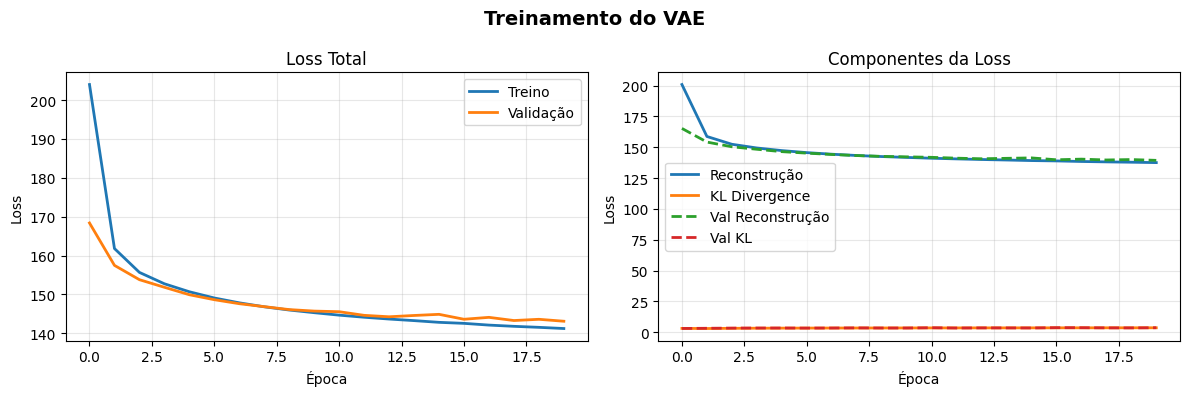

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


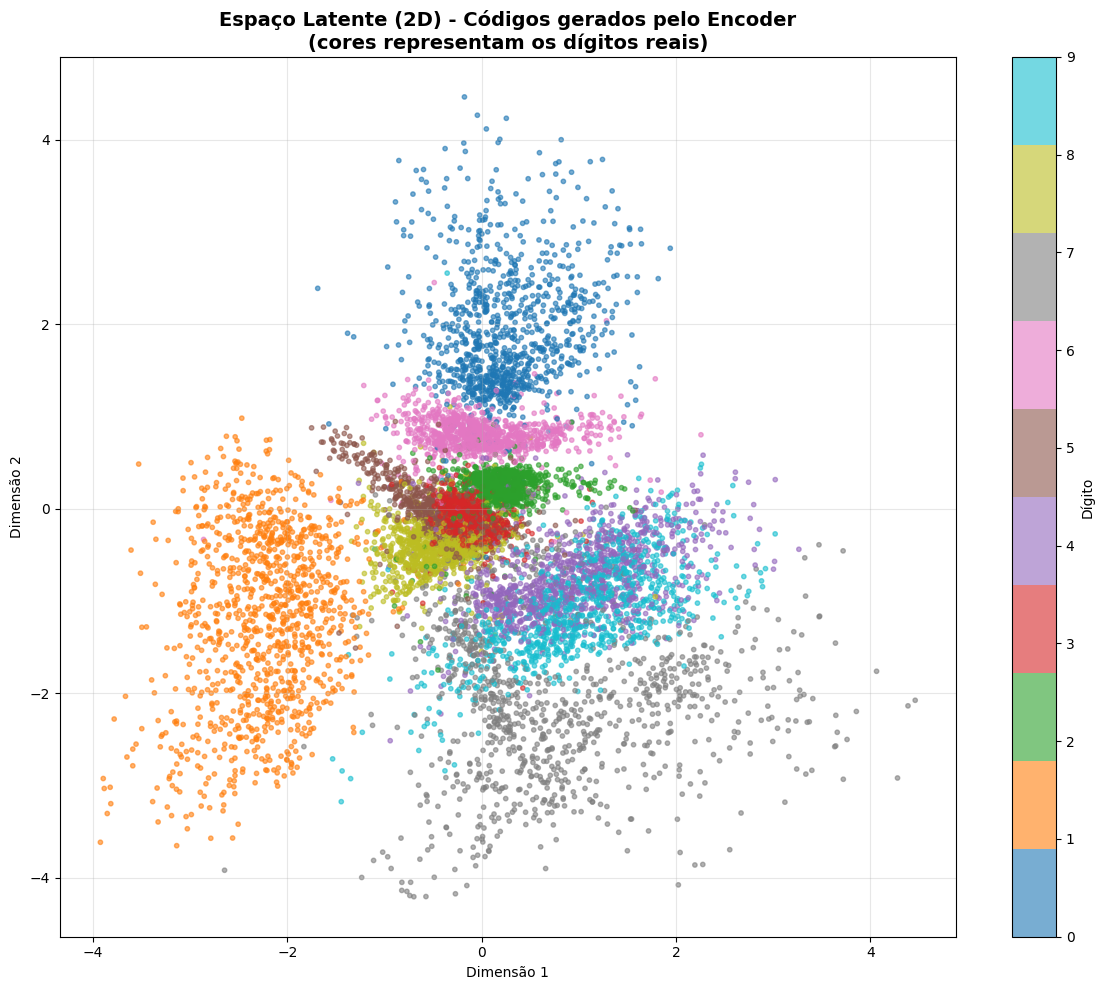

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


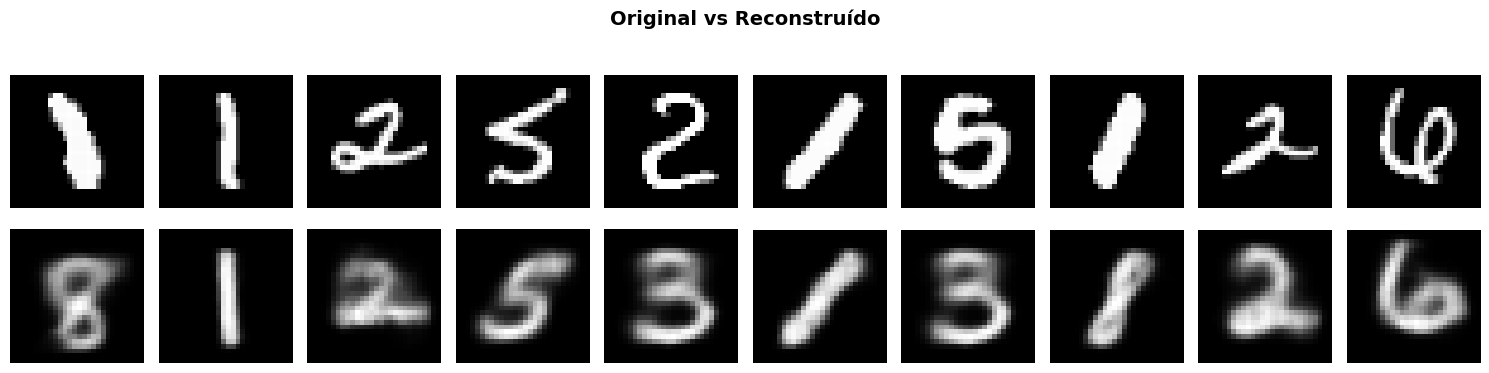

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


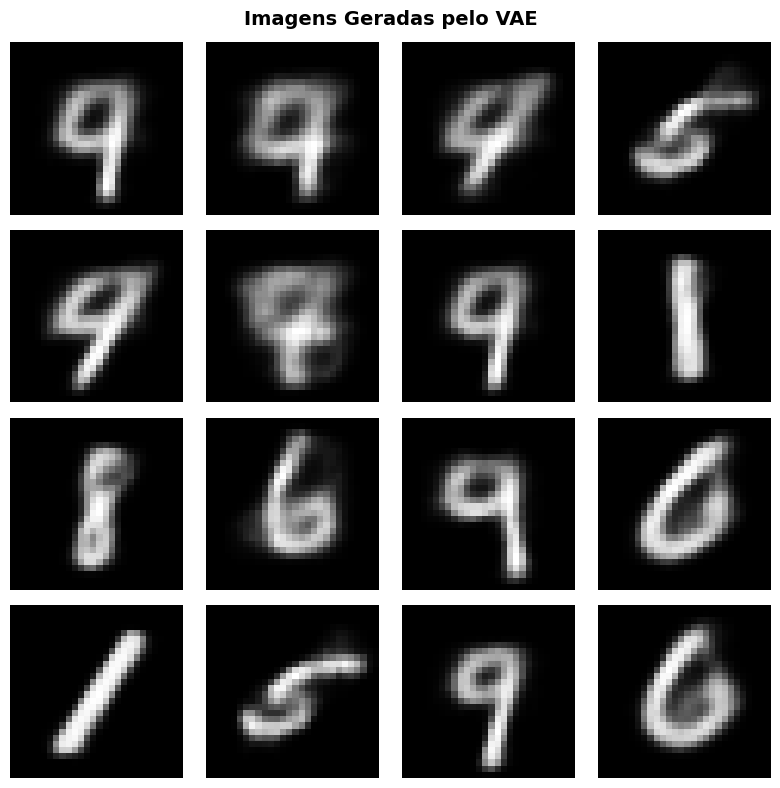

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


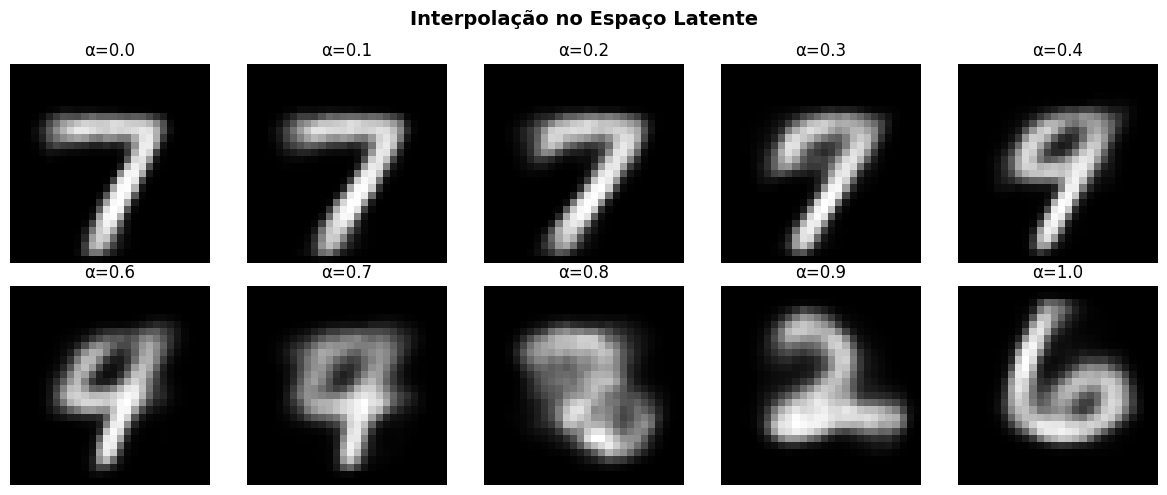


RESULTADOS DO VAE
Loss final: 141.2180
Reconstruction Loss final: 137.5470
KL Divergence final: 3.6710
Loss de validação final: 143.0936
Dimensão do espaço latente: 2


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Conv2DTranspose, Reshape, Input, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# ============================================
# 1. PARÂMETROS E CARREGAMENTO DOS DADOS
# ============================================

batch_size = 128
width = height = 28
latent_dim = 2  # Dimensão do espaço latente (para visualização)
nb_epochs = 20

# Carregar dados MNIST
(X_train, _), (X_test, _) = mnist.load_data()

# Normalizar e redimensionar
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, width, height, 1)
X_test = X_test.reshape(-1, width, height, 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# ============================================
# 2. ENCODER (COMPRESSÃO)
# ============================================

def build_encoder():
    encoder_input = Input(shape=(width, height, 1), name='encoder_input')

    # Camadas convolucionais
    x = Conv2D(32, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(encoder_input)
    x = Conv2D(64, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = Conv2D(128, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)

    # Flatten e camadas densas
    x = Flatten()(x)

    # Média e variância do espaço latente
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)

    return Model(encoder_input, [z_mean, z_log_var], name='encoder')

# ============================================
# 3. DECODER (RECONSTRUÇÃO) - CORRIGIDO
# ============================================

def build_decoder():
    decoder_input = Input(shape=(latent_dim,), name='decoder_input')

    # Calcular o tamanho após as convoluções para chegar em 28x28
    # 4x4 -> 8x8 (strides=2) -> 16x16 (strides=2) -> 32x32 (strides=2)
    # Precisamos cortar para 28x28
    x = Dense(4 * 4 * 128, activation='relu')(decoder_input)
    x = Reshape((4, 4, 128))(x)

    # Convoluções transpostas (decodificação)
    x = Conv2DTranspose(64, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)  # 8x8
    x = Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)  # 16x16
    x = Conv2DTranspose(1, kernel_size=(3, 3), strides=(2, 2), activation='sigmoid', padding='same')(x)   # 32x32

    # Cortar para 28x28 (remover 2 pixels de cada lado)
    x = Cropping2D(cropping=((2, 2), (2, 2)))(x)  # 32x32 -> 28x28

    return Model(decoder_input, x, name='decoder')

# ============================================
# 4. MODELO VAE COMPLETO
# ============================================

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def reparameterize(self, z_mean, z_log_var):
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def train_step(self, data):
        # Para autoencoder, x e y são os mesmos
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x)
            z = self.reparameterize(z_mean, z_log_var)
            reconstructed = self.decoder(z)

            # Loss de reconstrução (binary crossentropy)
            # As dimensões agora são as mesmas: (None, 28, 28, 1)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(x, reconstructed), axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(x, reconstructed), axis=(1, 2)
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

# ============================================
# 5. CONSTRUIR E TREINAR O VAE
# ============================================

# Construir encoder e decoder
encoder = build_encoder()
decoder = build_decoder()

# Verificar dimensões de saída
test_input = tf.random.normal((1, 28, 28, 1))
_, _ = encoder(test_input)
test_z = tf.random.normal((1, latent_dim))
test_output = decoder(test_z)
print(f"Decoder output shape: {test_output.shape}")  # Deve ser (1, 28, 28, 1)

# Criar VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=0.001))

# Mostrar arquiteturas
print("="*60)
print("ENCODER ARCHITECTURE")
print("="*60)
encoder.summary()

print("\n" + "="*60)
print("DECODER ARCHITECTURE")
print("="*60)
decoder.summary()

print("\n" + "="*60)
print("VAE ARCHITECTURE")
print("="*60)
vae.summary()

# ============================================
# 6. TREINAMENTO
# ============================================

print("\n" + "="*60)
print("TRAINING VAE")
print("="*60)

history = vae.fit(X_train, X_train,
                  epochs=nb_epochs,
                  batch_size=batch_size,
                  validation_data=(X_test, X_test),
                  verbose=1)

# ============================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ============================================

# Plotar loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Treinamento do VAE', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_title('Loss Total')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['reconstruction_loss'], label='Reconstrução', linewidth=2)
axes[1].plot(history.history['kl_loss'], label='KL Divergence', linewidth=2)
axes[1].plot(history.history['val_reconstruction_loss'], label='Val Reconstrução', linewidth=2, linestyle='--')
axes[1].plot(history.history['val_kl_loss'], label='Val KL', linewidth=2, linestyle='--')
axes[1].set_title('Componentes da Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. VISUALIZAÇÃO DO ESPAÇO LATENTE
# ============================================

# Codificar os dados de teste
z_mean, z_log_var = encoder.predict(X_test)

# Usar labels reais para colorir
_, y_test = mnist.load_data()
y_test = y_test[1]

plt.figure(figsize=(12, 10))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Dígito')
plt.title('Espaço Latente (2D) - Códigos gerados pelo Encoder\n(cores representam os dígitos reais)',
          fontsize=14, fontweight='bold')
plt.xlabel('Dimensão 1')
plt.ylabel('Dimensão 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 9. RECONSTRUÇÃO DE IMAGENS
# ============================================

n_images = 10

# Selecionar imagens aleatórias
indices = np.random.choice(len(X_test), n_images, replace=False)
test_images = X_test[indices]

# Codificar e decodificar
z_mean, _ = encoder.predict(test_images)
reconstructed = decoder.predict(z_mean)

# Plotar originais e reconstruídos
fig, axes = plt.subplots(2, n_images, figsize=(15, 4))
fig.suptitle('Original vs Reconstruído', fontsize=14, fontweight='bold')

for i in range(n_images):
    # Original
    axes[0, i].imshow(test_images[i].reshape(width, height), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12, fontweight='bold')

    # Reconstruído
    axes[1, i].imshow(reconstructed[i].reshape(width, height), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstruído', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 10. GERAÇÃO DE NOVAS IMAGENS
# ============================================

# Amostrar do espaço latente
n_samples = 16
random_latent = np.random.normal(size=(n_samples, latent_dim))

# Gerar imagens
generated = decoder.predict(random_latent)

# Plotar imagens geradas
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Imagens Geradas pelo VAE', fontsize=14, fontweight='bold')

for i in range(4):
    for j in range(4):
        axes[i, j].imshow(generated[i*4 + j].reshape(width, height), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 11. INTERPOLAÇÃO NO ESPAÇO LATENTE
# ============================================

# Selecionar duas imagens
img1 = X_test[0]
img2 = X_test[100]

# Codificar
z1, _ = encoder.predict(img1.reshape(1, width, height, 1))
z2, _ = encoder.predict(img2.reshape(1, width, height, 1))

# Interpolar
alphas = np.linspace(0, 1, 10)
interpolated = []

for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    img_interp = decoder.predict(z_interp)
    interpolated.append(img_interp[0])

# Plotar interpolação
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Interpolação no Espaço Latente', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(interpolated[i].reshape(width, height), cmap='gray')
    ax.set_title(f'α={alphas[i]:.1f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 12. RESULTADOS FINAIS
# ============================================

print("\n" + "="*60)
print("RESULTADOS DO VAE")
print("="*60)
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Reconstruction Loss final: {history.history['reconstruction_loss'][-1]:.4f}")
print(f"KL Divergence final: {history.history['kl_loss'][-1]:.4f}")
print(f"Loss de validação final: {history.history['val_loss'][-1]:.4f}")
print(f"Dimensão do espaço latente: {latent_dim}")
print("="*60)

###ResNet - Residual network

In [ ]:
from tensorflow.keras.layers import Add, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet50_custom(input_shape=(224, 224, 3), num_classes=1000):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same')(x)

    # Blocos residuais
    for filters in [64, 128, 256, 512]:
        for i in range(3):
            stride = 2 if i == 0 and filters > 64 else 1
            x = residual_block(x, filters, stride=stride)

    x = GlobalAveragePooling2D()(x)
    x = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, x)

###DenseNet (Densely Connected Convolutional Networks)


In [ ]:
from tensorflow.keras.layers import Concatenate

def dense_block(x, growth_rate, layers):
    for i in range(layers):
        conv = BatchNormalization()(x)
        conv = Activation('relu')(conv)
        conv = Conv2D(growth_rate, 3, padding='same')(conv)
        x = Concatenate()([x, conv])
    return x

def transition_layer(x, reduction=0.5):
    filters = int(x.shape[-1] * reduction)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 1, padding='same')(x)
    x = AveragePooling2D(2, strides=2)(x)
    return x

def build_densenet121(input_shape=(224, 224, 3), num_classes=1000):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same')(x)

    # Dense blocks com transition layers
    growth_rate = 32
    block_layers = [6, 12, 24, 16]

    for i, layers in enumerate(block_layers):
        x = dense_block(x, growth_rate, layers)
        if i < len(block_layers) - 1:
            x = transition_layer(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, x)

###Inception (GoogLeNet)


In [ ]:
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                      filters_5x5_reduce, filters_5x5, filters_pool_proj):

    # Branch 1: 1x1 convolution
    branch1 = Conv2D(filters_1x1, 1, padding='same', activation='relu')(x)

    # Branch 2: 1x1 -> 3x3
    branch2 = Conv2D(filters_3x3_reduce, 1, padding='same', activation='relu')(x)
    branch2 = Conv2D(filters_3x3, 3, padding='same', activation='relu')(branch2)

    # Branch 3: 1x1 -> 5x5
    branch3 = Conv2D(filters_5x5_reduce, 1, padding='same', activation='relu')(x)
    branch3 = Conv2D(filters_5x5, 5, padding='same', activation='relu')(branch3)

    # Branch 4: MaxPool -> 1x1
    branch4 = MaxPooling2D(3, strides=1, padding='same')(x)
    branch4 = Conv2D(filters_pool_proj, 1, padding='same', activation='relu')(branch4)

    return Concatenate()([branch1, branch2, branch3, branch4])

###EfficientNet

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Usando EfficientNet pré-treinada
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

### GRU (Gated Recurrent Unit)

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional

def build_gru_model(input_shape, num_classes):
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

###Bidirectional LSTM

In [ ]:
def build_bidirectional_lstm(vocab_size, embedding_dim, max_length, num_classes):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(64)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

###CNN-LSTM (Convolutional LSTM)

In [ ]:
def build_cnn_lstm(timesteps, height, width, channels, num_classes):
    model = Sequential([
        TimeDistributed(Conv2D(32, (3, 3), activation='relu'),
                        input_shape=(timesteps, height, width, channels)),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Flatten()),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

###GAN (Generative Adversarial Network)

In [ ]:
def build_generator(latent_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim, activation='relu'),
        Dense(256, activation='relu'),
        Dense(512, activation='relu'),
        Dense(28*28*1, activation='tanh'),
        Reshape((28, 28, 1))
    ])
    return model

def build_discriminator(input_shape):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_gan(generator, discriminator):
    discriminator.trainable = False
    gan = Sequential([generator, discriminator])
    return gan

### DCGAN (Deep Convolutional GAN)

In [ ]:
def build_dcgan_generator(latent_dim):
    model = Sequential([
        Dense(7*7*256, use_bias=False, input_shape=(latent_dim,)),
        BatchNormalization(),
        Activation('relu'),
        Reshape((7, 7, 256)),

        Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        BatchNormalization(),
        Activation('relu'),

        Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        BatchNormalization(),
        Activation('relu'),

        Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        Activation('tanh')
    ])
    return model

###Transformer

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Attention
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed Forward
    residual = x
    x = Dense(ff_dim, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = Add()([x, residual])
    x = LayerNormalization(epsilon=1e-6)(x)

    return x

def build_transformer(max_length, vocab_size, embedding_dim, num_classes):
    inputs = Input(shape=(max_length,))
    x = Embedding(vocab_size, embedding_dim)(inputs)

    # Transformer blocks
    for _ in range(4):
        x = transformer_encoder(x, head_size=embedding_dim, num_heads=8, ff_dim=embedding_dim*4)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

###BERT (Bidirectional Encoder Representations from Transformers)

In [ ]:
from transformers import TFBertModel

def build_bert_classifier(num_classes):
    # Carregar BERT pré-treinado
    bert_model = TFBertModel.from_pretrained('bert-base-uncased')

    input_ids = Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

    bert_output = bert_model(input_ids, attention_mask=attention_mask)
    pooled_output = bert_output.pooler_output
    x = Dense(128, activation='relu')(pooled_output)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=outputs)
    return model

###Vision Transformer (ViT)

In [ ]:
def build_vit(input_shape=(224, 224, 3), patch_size=16, num_patches=196,
              projection_dim=768, num_heads=12, num_layers=12, num_classes=1000):

    inputs = Input(shape=input_shape)

    # Patch embedding
    patches = Conv2D(projection_dim, patch_size, strides=patch_size, padding='valid')(inputs)
    patches = Reshape((num_patches, projection_dim))(patches)

    # Position embedding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = Embedding(num_patches, projection_dim)(positions)

    x = Add()([patches, position_embedding])

    # Transformer encoder blocks
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size=projection_dim, num_heads=num_heads, ff_dim=projection_dim*4)

    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, x)

###Redes Siamesas

In [ ]:
def build_siamese_network(input_shape):
    # Base network (shared weights)
    base_network = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu')
    ])

    # Two input branches
    input_a = Input(shape=input_shape)
    input_b = Input(shape=input_shape)

    # Encoded features
    encoded_a = base_network(input_a)
    encoded_b = base_network(input_b)

    # Distance layer
    distance = Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([encoded_a, encoded_b])
    x = Dense(64, activation='relu')(distance)
    output = Dense(1, activation='sigmoid')(x)

    return Model([input_a, input_b], output)

###Redes de Capsule (CapsNet)

In [ ]:
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())
    return scale * vectors

class CapsuleLayer(Layer):
    def __init__(self, num_capsules, capsule_dim, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        self.routings = routings

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.num_capsules * self.capsule_dim),
                                 initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        inputs_expand = tf.expand_dims(inputs, 2)
        inputs_tiled = tf.tile(inputs_expand, [1, 1, self.num_capsules, 1])
        u_hat = tf.reduce_sum(inputs_tiled * self.W, axis=3)
        u_hat = tf.reshape(u_hat, (-1, inputs.shape[1], self.num_capsules, self.capsule_dim))

        b = tf.zeros(shape=(tf.shape(inputs)[0], inputs.shape[1], self.num_capsules))
        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=-1)
            s = tf.reduce_sum(tf.expand_dims(c, -1) * u_hat, axis=1)
            v = squash(s)
            if i < self.routings - 1:
                b += tf.reduce_sum(u_hat * tf.expand_dims(v, 1), axis=-1)
        return v

def build_capsnet(input_shape=(28, 28, 1), num_classes=10):
    inputs = Input(shape=input_shape)

    # Convolutional layer
    x = Conv2D(256, (9, 9), activation='relu')(inputs)

    # Primary Capsules
    x = Conv2D(256, (9, 9), strides=2, padding='valid')(x)
    x = Reshape((-1, 8))(x)
    x = squash(x)

    # Digit Capsules
    digit_caps = CapsuleLayer(num_capsules=num_classes, capsule_dim=16)(x)

    # Output
    outputs = Lambda(lambda x: tf.norm(x, axis=-1))(digit_caps)

    return Model(inputs, outputs)

## Tabela conclusiva


| Modelo | Descrição | Melhor para | Vantagens | Desvantagens |
|--------|-----------|-------------|-----------|--------------|
| **LSTM** | Rede recorrente com memória de longo prazo | Séries temporais, texto, áudio, previsão de sequências | - Captura dependências de longo prazo<br>- Evita vanishing gradient<br>- Lida bem com sequências | - Computacionalmente caro<br>- Pode overfitar<br>- Difícil paralelizar |
| **Autoencoder** | Rede que aprende a reconstruir suas entradas | Redução de dimensionalidade, extração de features, compressão | - Aprendizagem não supervisionada<br>- Reduz ruído<br>- Compacta informações | - Pode perder informação relevante<br>- Requer muitos dados<br>- Difícil interpretar features |
| **Denoising Autoencoder** | Autoencoder treinado com dados ruidosos | Remoção de ruído, reconstrução de imagens | - Robusto a ruído<br>- Aprende features mais robustas<br>- Melhor generalização | - Mais lento para treinar<br>- Requer dados ruidosos<br>- Pode suavizar detalhes |
| **VAE** | Autoencoder com espaço latente probabilístico | Geração de dados, aprendizado não supervisionado | - Gera novos dados realistas<br>- Espaço latente contínuo<br>- Interpretável | - Imagens podem ficar borradas<br>- Difícil treinar<br>- Posterior mismatch |
| **ResNet** | Conexões residuais (skip connections) | Visão computacional, classificação de imagens | - Treina redes muito profundas<br>- Evita vanishing gradient<br>- Convergência mais rápida | - Mais parâmetros<br>- Pode ser overkill para problemas simples<br>- Memória intensiva |
| **DenseNet** | Conexões densas entre todas as camadas | Visão computacional, segmentação | - Reutilização eficiente de features<br>- Menos parâmetros que ResNet<br>- Melhor fluxo de gradiente | - Alta complexidade de memória<br>- Implementação complexa<br>- Treinamento mais lento |
| **Inception** | Múltiplos kernels de diferentes tamanhos | Visão computacional, classificação | - Captura features em múltiplas escalas<br>- Uso eficiente de parâmetros<br>- Boa performance | - Arquitetura complexa<br>- Difícil de modificar<br>- Overfitting em datasets pequenos |
| **EfficientNet** | Escalonamento balanceado de rede | Visão computacional, eficiência computacional | - Alta acurácia com menos parâmetros<br>- Otimizado para eficiência<br>- Vários tamanhos disponíveis | - Complexidade de implementação<br>- Pré-treinamento pesado<br>- Não tão flexível |
| **Transformer** | Mecanismo de atenção self-attention | NLP, tradução, texto | - Processamento paralelo<br>- Captura dependências longas<br>- State-of-the-art em NLP | - Muito pesado<br>- Requer muitos dados<br>- Computacionalmente caro |
| **BERT** | Bidirectional Encoder Representations | Compreensão de linguagem, classificação de texto | - Contexto bidirecional<br>- Pré-treinado em texto<br>- Fine-tuning eficiente | - Muito grande (muitos parâmetros)<br>- Lento para treinar<br>- Requer GPU poderosa |
| **Vision Transformer (ViT)** | Transformer para imagens | Visão computacional, classificação de imagens | - Escala bem com dados<br>- Captura relações globais<br>- Arquitetura uniforme | - Requer muitos dados<br>- Pode perder informações locais<br>- Não tão eficiente quanto CNN |
| **GAN** | Rede geradora e discriminadora competitiva | Geração de imagens, arte, dados sintéticos | - Gera imagens realistas<br>- Aprendizagem adversarial<br>- Cria dados variados | - Treinamento instável<br>- Mode collapse<br>- Difícil balancear gerador/discriminador |
| **DCGAN** | GAN convolucional profunda | Geração de imagens | - Imagens de melhor qualidade<br>- Arquitetura estável<br>- Boa para imagens | - Ainda pode colapsar<br>- Critério de parada difícil<br>- Sensível a hiperparâmetros |
| **CNN-LSTM** | Convolução + LSTM | Vídeos, séries temporais de imagens, captação de movimento | - Captura padrões espaciais e temporais<br>- Ideal para vídeos<br>- Reconhecimento de atividades | - Complexo<br>- Pode ser lento<br>- Requer muitos dados |
| **Bidirectional LSTM** | LSTM com forward/backward | Processamento de sequências (contexto completo), classificação de texto | - Contexto bidirecional<br>- Melhor para classificação de sentenças<br>- Mais informação | - Não pode ser usado para previsão em tempo real<br>- Mais lento<br>- Requer sequência completa |
| **GRU** | Versão simplificada do LSTM | Séries temporais, quando recurso é limitado | - Mais rápido que LSTM<br>- Menos parâmetros<br>- Performance similar | - Menos capacidade que LSTM<br>- Pode não capturar dependências muito longas<br>- Menos flexível |
| **Siamese Network** | Duas redes que compartilham pesos | Similaridade, face recognition, verificação | - Aprende embeddings de similaridade<br>- Funciona com poucos exemplares<br>- Boa para one-shot learning | - Treinamento complexo<br>- Requer pares de dados<br>- Difícil balancear |
| **Capsule Network (CapsNet)** | Cápsulas que preservam hierarquias | Reconhecimento de poses, rotações | - Preserva relações espaciais<br>- Robustez a rotações<br>- Interpretabilidade | - Complexidade computacional<br>- Difícil treinar<br>- Não escala bem |
| **Transformer (Só Decoder)** | GPT, modelos generativos | Geração de texto, chatbot, completude | - Geração fluente<br>- Contexto longo<br>- Escala bem | - Pode gerar texto repetitivo<br>- Alucinações<br>- Computacionalmente pesado |

##Exercício aula 2
crie um algoritmo para o seguinte:
- CIFAR-10 dataset

- banco de dados de immagens coloridas em 32x32 pixels
- 10 categorias - 6000 imagens por categoria
- 50000 imagens para treinamento
- 10000 imagens para teste

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
DATASET CIFAR-10
Formato X_train: (50000, 32, 32, 3)
Formato y_train: (50000, 1)
Formato X_test: (10000, 32, 32, 3)
Formato y_test: (10000, 1)
Número de classes: 10
Classes: ['Avião', 'Automóvel', 'Pássaro', 'Gato', 'Veado', 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']

Distribuição das classes no treino:
  Avião: 5000 imagens
  Automóvel: 5000 imagens
  Pássaro: 5000 imagens
  Gato: 5000 imagens
  Veado: 5000 imagens
  Cachorro: 5000 imagens
  Sapo: 5000 imagens
  Cavalo: 5000 imagens
  Navio: 5000 imagens
  Caminhão: 5000 imagens


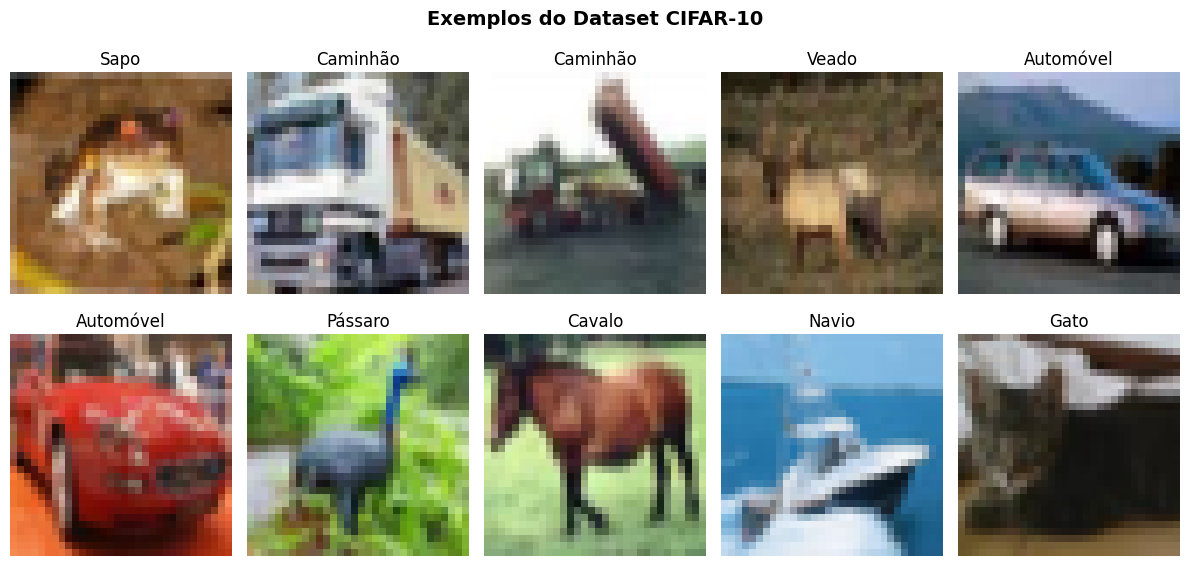


X_train após normalização: min=0.00, max=1.00
y_train_cat shape: (50000, 10)

Data augmentation configurado:
  - Rotação: ±15°
  - Deslocamento: ±10%
  - Espelhamento horizontal
  - Zoom: ±10%

ARQUITETURA DO MODELO


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 734,282 (2.80 MB)

 Trainable params: 732,042 (2.79 MB)

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 8: val_accuracy did not improve from 0.66780
781/781 ━━━━━━━━━━━━━━━━━━━━ 101s 127ms/step - accuracy: 0.6875 - loss: 0.8374 - val_accuracy: 0.6217 - val_loss: 1.1979 - learning_rate: 0.0010
Epoch 9/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7387 - loss: 0.7587
Epoch 9: val_accuracy improved from 0.66780 to 0.67770, saving model to melhor_modelo_cifar10.h5



Epoch 9: finished saving model to melhor_modelo_cifar10.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1684s 2s/step - accuracy: 0.7469 - loss: 0.7367 - val_accuracy: 0.6777 - val_loss: 0.9866 - learning_rate: 0.0010
Epoch 10/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 14:41 1s/step - accuracy: 0.7812 - loss: 0.9075
Epoch 10: val_accuracy improved from 0.67770 to 0.68330, saving model to melhor_modelo_cifar10.h5



Epoch 10: finished saving model to melhor_modelo_cifar10.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.7812 - loss: 0.9075 - val_accuracy: 0.6833 - val_loss: 0.9771 - learning_rate: 0.0010
Epoch 11/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7656 - loss: 0.6874
Epoch 11: val_accuracy improved from 0.68330 to 0.71560, saving model to melhor_modelo_cifar10.h5



Epoch 11: finished saving model to melhor_modelo_cifar10.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1146s 1s/step - accuracy: 0.7696 - loss: 0.6757 - val_accuracy: 0.7156 - val_loss: 0.8605 - learning_rate: 0.0010
Epoch 12/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 16:35 1s/step - accuracy: 0.7188 - loss: 0.6957
Epoch 12: val_accuracy did not improve from 0.71560
781/781 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.7188 - loss: 0.6957 - val_accuracy: 0.7134 - val_loss: 0.8796 - learning_rate: 0.0010
Epoch 13/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7866 - loss: 0.6292

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Activation, Input, Add
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. CARREGAMENTO E EXPLORAÇÃO DOS DADOS
# ============================================

# Carregar dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Classes do CIFAR-10
classes = ['Avião', 'Automóvel', 'Pássaro', 'Gato', 'Veado',
           'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']

print("="*60)
print("DATASET CIFAR-10")
print("="*60)
print(f"Formato X_train: {X_train.shape}")  # (50000, 32, 32, 3)
print(f"Formato y_train: {y_train.shape}")  # (50000, 1)
print(f"Formato X_test: {X_test.shape}")    # (10000, 32, 32, 3)
print(f"Formato y_test: {y_test.shape}")    # (10000, 1)
print(f"Número de classes: {len(classes)}")
print(f"Classes: {classes}")

# Verificar distribuição das classes
unique, counts = np.unique(y_train, return_counts=True)
print("\nDistribuição das classes no treino:")
for label, count in zip(unique, counts):
    print(f"  {classes[label]}: {count} imagens")

# ============================================
# 2. VISUALIZAÇÃO DOS DADOS
# ============================================

# Visualizar algumas imagens
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Exemplos do Dataset CIFAR-10', fontsize=14, fontweight='bold')

for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_train[i])
    axes[row, col].set_title(classes[y_train[i][0]])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 3. PRÉ-PROCESSAMENTO
# ============================================

# Normalizar pixels (0-255) para (0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Converter labels para one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\nX_train após normalização: min={X_train.min():.2f}, max={X_train.max():.2f}")
print(f"y_train_cat shape: {y_train_cat.shape}")

# ============================================
# 4. DATA AUGMENTATION (Aumento de dados)
# ============================================

datagen = ImageDataGenerator(
    rotation_range=15,        # Rotação aleatória de 15 graus
    width_shift_range=0.1,    # Deslocamento horizontal
    height_shift_range=0.1,   # Deslocamento vertical
    horizontal_flip=True,     # Espelhamento horizontal
    zoom_range=0.1,           # Zoom aleatório
    fill_mode='nearest'       # Preenchimento de pixels vazios
)

# Aplicar data augmentation apenas nos dados de treino
datagen.fit(X_train)

print("\nData augmentation configurado:")
print("  - Rotação: ±15°")
print("  - Deslocamento: ±10%")
print("  - Espelhamento horizontal")
print("  - Zoom: ±10%")

# ============================================
# 5. MODELO 1: CNN SIMPLES (BASELINE)
# ============================================

def build_simple_cnn():
    model = Sequential()

    # Primeiro bloco convolucional
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Segundo bloco convolucional
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Terceiro bloco convolucional
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Camadas densas
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

# ============================================
# 6. MODELO 2: CNN COM BATCH NORMALIZATION
# ============================================

def build_cnn_batchnorm():
    model = Sequential()

    # Primeiro bloco
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Segundo bloco
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Terceiro bloco
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Camadas densas
    model.add(Flatten())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

# ============================================
# 7. MODELO 3: RESIDUAL NETWORK (RESNET)
# ============================================

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # Caminho principal
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Ajustar shortcut se necessário
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

def build_resnet():
    inputs = Input(shape=(32, 32, 3))

    # Primeira convolução
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Blocos residuais
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Global average pooling
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# ============================================
# 8. TREINAMENTO DO MODELO ESCOLHIDO
# ============================================

# Escolher o modelo (pode trocar entre os três)
# model = build_simple_cnn()
# model = build_cnn_batchnorm()
model = build_resnet()  # ResNet geralmente tem melhor performance

# Compilar modelo
initial_learning_rate = 0.001
model.compile(
    optimizer=Adam(learning_rate=initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('melhor_modelo_cifar10.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Mostrar arquitetura do modelo
print("\n" + "="*60)
print("ARQUITETURA DO MODELO")
print("="*60)
model.summary()

# ============================================
# 9. TREINAMENTO
# ============================================

print("\n" + "="*60)
print("TREINAMENTO")
print("="*60)

epochs = 50
batch_size = 64

# Treinar com data augmentation
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=len(X_train) // batch_size,
    callbacks=callbacks,
    verbose=1
)

# ============================================
# 10. VISUALIZAÇÃO DO TREINAMENTO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizado - CIFAR-10', fontsize=14, fontweight='bold')

# Acurácia
axes[0].plot(history.history['accuracy'], label='Treino', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Treino', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 11. AVALIAÇÃO DO MODELO
# ============================================

# Avaliar no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Acurácia no teste: {test_acc:.4f}")

# Predições
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_classes, target_names=classes))

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - CIFAR-10', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================
# 12. VISUALIZAÇÃO DE PREDIÇÕES CORRETAS E INCORRETAS
# ============================================

# Encontrar predições corretas e incorretas
correct_indices = np.where(y_pred_classes == y_true)[0]
incorrect_indices = np.where(y_pred_classes != y_true)[0]

print(f"\nPredições corretas: {len(correct_indices)}")
print(f"Predições incorretas: {len(incorrect_indices)}")

# Mostrar algumas predições corretas
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Predições Corretas', fontsize=14, fontweight='bold')

for i, idx in enumerate(correct_indices[:10]):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_test[idx])
    axes[row, col].set_title(f'Real: {classes[y_true[idx]]}\nPred: {classes[y_pred_classes[idx]]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Mostrar algumas predições incorretas
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Predições Incorretas', fontsize=14, fontweight='bold')

for i, idx in enumerate(incorrect_indices[:10]):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_test[idx])
    axes[row, col].set_title(f'Real: {classes[y_true[idx]]}\nPred: {classes[y_pred_classes[idx]]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 13. VISUALIZAÇÃO DOS FILTROS (PRIMEIRA CAMADA)
# ============================================

# Extrair filtros da primeira camada convolucional
first_conv_layer = None
for layer in model.layers:
    if isinstance(layer, Conv2D):
        first_conv_layer = layer
        break

if first_conv_layer:
    weights = first_conv_layer.get_weights()[0]
    weights = weights[:, :, :, :32]  # Pegar primeiros 32 filtros

    # Normalizar para visualização
    weights_min, weights_max = weights.min(), weights.max()
    weights = (weights - weights_min) / (weights_max - weights_min)

    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    fig.suptitle('Filtros da Primeira Camada Convolucional', fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < 32:
            ax.imshow(weights[:, :, 0, i], cmap='viridis')
            ax.set_title(f'Filtro {i+1}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ============================================
# 14. SALVAR E CARREGAR O MODELO
# ============================================

# Salvar o modelo
model.save('modelo_cifar10_final.h5')
print("\n✅ Modelo salvo como 'modelo_cifar10_final.h5'")

# Opção para carregar o modelo posteriormente
# from tensorflow.keras.models import load_model
# modelo_carregado = load_model('modelo_cifar10_final.h5')

# ============================================
# 15. RESUMO FINAL
# ============================================

print("\n" + "="*60)
print("RESUMO FINAL - CIFAR-10")
print("="*60)
print(f"Dataset: CIFAR-10")
print(f"Imagens: 32x32 pixels coloridas (RGB)")
print(f"Classes: 10 categorias")
print(f"Treino: 50.000 imagens")
print(f"Teste: 10.000 imagens")
print(f"Modelo: ResNet personalizada")
print(f"Data augmentation: Aplicado")
print(f"Épocas treinadas: {len(history.history['loss'])}")
print(f"Melhor acurácia de validação: {max(history.history['val_accuracy']):.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")
print("="*60)

#Aula 3 - Aplicações de Métodos Não Supervisionados


##Exemplos

###PCA - Sklearn

In [ ]:
pca = PCA()
scaler = StandardScaler()
logistic = LogisticRegression(max_iter=1000, tol=0.1)

pipe = Pipeline([('scaler', scaler), ('pca', pca), ('logistic', logistic)])

param_grid = {
    'pca__n_components': [3,5,7,10,15,17,18,19,20,21,22,23,24,25],
    'logistic__C': np.logspace(-4, 4, 4)
}

search = GridSearchCV(pipe, param_grid, n_jobs=2)
search.fit(X,)

###PCA - MNIST

In [ ]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits= load_digits()

pca=PCA(n_components=36, whiten=True)
X_pca=pca.fit_transform(digits.data / 255)

print(pca.explained_variance_ratio_)

###Algorítmo - K-Means

In [ ]:
from sklearn.cluster import KMeans

nbb_clusters = [2,3,5,6,7,8,9,10]

insertias = []

for n in nb_clusters:
  km = KMeans(n_clusters=n)
  km.fit(X)
  inertias.append(km.inertia_)

plt_aics = plt.figure()
plt.plot(intertias)
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

###Silhouette score

In [ ]:
from sklearn.metrics import silhouette_score

nb_clusters = [2,3,5,6,7,8,9,10]

avg_silhouette = []

for n in nb_clusters:
  km = KMeans(n_clusters=n)
  km.fit_predict(X)
  avg_silhouette.append(silhouette_score(X, Y))

plt_aics = plt.figure()
plt.plot(avg_silhouettes)
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.show()

###Clusterização hierarquica

In [ ]:
from sklearn.datasets import make_blobs

nb_samples=25
X, Y = make_blobs(n_samples=nb_samples, n_features=2,centers=3,cluster_std=1.5)

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

Xdist = pdist(X, metric='euclidean')
Xl = linkage(Xdist, method='ward')
Xd = dedrogram(Xl)


Xdist = pdist(X, metric='euclidean')
Xl = linkage(Xdist, method='complete')
Xd = dedrogram(Xl)
ac = AgglomerativeClustering(n_clusters=8, linkage='complete')
Y_pred = ac.fit_predict(X)
print('Silhouette score (Complete): %.3f' % silhouette_score(X, Y_pred))
print('Adjusted Rand score (Complete): %.3f' % adjusted_rand_score(Y, Y_pred))


Xdist = pdist(X, metric='euclidean')
Xl = linkage(Xdist, method='avarage')
Xd = dedrogram(Xl)
ac = AgglomerativeClustering(n_clusters=8, linkage='Avarage')
Y_pred = ac.fit_predict(X)
print('Silhouette score (Avarage): %.3f' % silhouette_score(X, Y_pred))
print('Adjusted Rand score (Avarage): %.3f' % adjusted_rand_score(Y, Y_pred))


Xdist = pdist(X, metric='euclidean')
Xl = linkage(Xdist, method='ward')
Xd = dedrogram(Xl)
ac = AgglomerativeClustering(n_clusters=8, linkage='ward')
Y_pred = ac.fit_predict(X)
print('Silhouette score (Ward): %.3f' % silhouette_score(X, Y_pred))
print('Adjusted Rand score (Ward): %.3f' % adjusted_rand_score(Y, Y_pred))



###DBScan

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

dbs = DBSCAN(eps=0.05)
moon_Y_db = dbs.fit_predict(moon_X)

###t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Aplicação: Visualização de dados de alta dimensão
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title('t-SNE - Visualização de Alta Dimensionalidade')
plt.show()

###UMAP (Uniform Manifold Approximation and Projection)

In [ ]:
# !pip install umap-learn
import umap

# Aplicação: Visualização e redução de dimensionalidade (mais rápido que t-SNE)
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.title('UMAP - Redução de Dimensionalidade')
plt.show()

###GMM (Gaussian Mixture Models)

In [ ]:
from sklearn.mixture import GaussianMixture

# Aplicação: Clusterização probabilística
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
y_pred = gmm.predict(X)
probs = gmm.predict_proba(X)  # Probabilidades de pertencimento

print(f"Log-likelihood: {gmm.score(X):.2f}")

###Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering

# Aplicação: Clusters baseados em conectividade (grafos)
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors',
                               random_state=42, n_neighbors=10)
y_pred = spectral.fit_predict(X)

###Mean Shift

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Aplicação: Clusterização baseada em densidade (sem definir k)
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
y_pred = meanshift.fit_predict(X)
print(f"Número de clusters encontrados: {len(np.unique(y_pred))}")

###BIRCH (Balanced Iterative Reducing and Clustering)

In [ ]:
from sklearn.cluster import Birch

# Aplicação: Clusterização em grandes datasets
birch = Birch(n_clusters=3, threshold=0.5, branching_factor=50)
y_pred = birch.fit_predict(X)

###OPTICS (Ordering Points To Identify the Clustering Structure)

In [ ]:
from sklearn.cluster import OPTICS

# Aplicação: Similar ao DBSCAN mas com melhor detecção de clusters de densidades variadas
optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
y_pred = optics.fit_predict(X)
clusters = optics.cluster_hierarchy_

### Isolation Forest (Detecção de Anomalias)

In [ ]:
from sklearn.ensemble import IsolationForest

# Aplicação: Detecção de outliers/anomalias
iso_forest = IsolationForest(contamination=0.1, random_state=42)
y_pred = iso_forest.fit_predict(X)  # -1 = anomalia, 1 = normal
anomaly_scores = iso_forest.score_samples(X)

### One-Class SVM (Detecção de Novidade)

In [ ]:
from sklearn.svm import OneClassSVM

# Aplicação: Detecção de novidades/outliers
ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='auto')
y_pred = ocsvm.fit_predict(X)  # -1 = outlier, 1 = inlier

### NMF (Non-negative Matrix Factorization)

In [ ]:
from sklearn.decomposition import NMF

# Aplicação: Decomposição de matrizes (imagens, texto)
nmf = NMF(n_components=10, init='random', random_state=42)
W = nmf.fit_transform(X)  # Features extraídas
H = nmf.components_       # Componentes

###ICA (Independent Component Analysis)

In [ ]:
from sklearn.decomposition import FastICA

# Aplicação: Separação de fontes (ex: áudio, EEG)
ica = FastICA(n_components=10, random_state=42)
X_ica = ica.fit_transform(X)

###Autoencoders (Deep Learning)

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Aplicação: Redução de dimensionalidade e extração de features
input_dim = X.shape[1]
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X, X, epochs=50, batch_size=256, shuffle=True)

###Mini-Batch K-Means

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# Aplicação: K-means para datasets muito grandes
mbk = MiniBatchKMeans(n_clusters=3, batch_size=100, random_state=42)
y_pred = mbk.fit_predict(X)

###Affinity Propagation

In [ ]:
from sklearn.cluster import AffinityPropagation

# Aplicação: Clusterização sem número pré-definido de clusters
ap = AffinityPropagation(damping=0.5, random_state=42)
y_pred = ap.fit_predict(X)
print(f"Número de clusters: {len(ap.cluster_centers_indices_)}")

###Agglomerative Clustering (diferentes linkages)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Aplicação: Clusterização hierárquica com diferentes métricas
linkages = ['ward', 'complete', 'average', 'single']
for linkage in linkages:
    clustering = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    y_pred = clustering.fit_predict(X)
    print(f"Linkage {linkage}: clusters formados")

##TAbela conclusiva


| Método | Descrição | Melhor para | Vantagens | Desvantagens |
|--------|-----------|-------------|-----------|--------------|
| **PCA** | Redução de dimensionalidade linear | Visualização, remoção de correlações, compressão | - Rápido<br>- Interpretável<br>- Remove ruído | - Assume linearidade<br>- Perde interpretabilidade dos componentes |
| **K-Means** | Clusterização por centroides | Segmentação de clientes, compressão de imagens | - Rápido e escalável<br>- Fácil implementação<br>- Funciona bem com dados esféricos | - Requer número de clusters (k)<br>- Sensível a outliers<br>- Clusters apenas esféricos |
| **Hierarchical Clustering** | Clusterização hierárquica (dendrograma) | Biologia (filogenética), análise exploratória | - Não requer k pré-definido<br>- Visualização hierárquica<br>- Determinístico | - Computacionalmente caro O(n³)<br>- Não escala bem<br>- Sensível a outliers |
| **DBSCAN** | Clusterização por densidade | Dados com ruído, formatos irregulares, detecção de outliers | - Encontra formatos arbitrários<br>- Identifica outliers<br>- Não requer k | - Sensível aos parâmetros (eps, min_samples)<br>- Problemas com densidades variadas |
| **t-SNE** | Visualização de alta dimensão | Visualização de dados complexos (imagens, texto) | - Preserva estruturas locais<br>- Ótimo para visualização<br>- Captura não-linearidades | - Muito lento<br>- Não determinístico<br>- Não preserva distâncias globais |
| **UMAP** | Redução de dimensionalidade | Visualização (alternativa ao t-SNE) | - Mais rápido que t-SNE<br>- Preserva topologia global<br>- Escalável | - Menos conhecido<br>- Parâmetros sensíveis |
| **GMM** | Clusterização probabilística | Dados com sobreposição, classificação suave | - Probabilidades de pertencimento<br>- Clusters elípticos<br>- Flexível | - Requer k<br>- Sensível a inicialização<br>- Pode overfitar |
| **Spectral Clustering** | Clusterização por espectro de grafos | Estruturas de grafos, imagens, dados conectados | - Captura estruturas complexas<br>- Funciona com dados não convexos<br>- Baseado em teoria de grafos | - Computacionalmente caro<br>- Sensível à construção do grafo<br>- Requer k |
| **Mean Shift** | Clusterização por deslocamento de modos | Visão computacional, segmentação de imagens | - Não requer k<br>- Encontra número automático de clusters<br>- Robusto a outliers | - Computacionalmente caro O(n²)<br>- Sensível à bandwidth<br>- Não escala bem |
| **BIRCH** | Clusterização hierárquica para grandes dados | Datasets muito grandes (>1e6 pontos) | - Muito rápido<br>- Escalável<br>- Funciona com dados streaming | - Sensível à ordem dos dados<br>- Clusters esféricos<br>- Parâmetros sensíveis |
| **OPTICS** | Clusterização por densidade (melhor que DBSCAN) | Densidades variadas, hierarquia de clusters | - Detecta clusters de densidades variadas<br>- Produz ordem de clusterização<br>- Mais robusto que DBSCAN | - Mais lento que DBSCAN<br>- Parâmetros ainda sensíveis<br>- Complexo |
| **Isolation Forest** | Detecção de anomalias | Detecção de fraudes, segurança, outliers | - Muito rápido<br>- Escalável<br>- Funciona em alta dimensão | - Assume anomalias raras e distintas<br>- Parâmetro contamination sensível |
| **One-Class SVM** | Detecção de novidades | Controle de qualidade, detecção de anomalias | - Baseado em teoria estatística<br>- Bom para dados de alta dimensão | - Lento para grandes datasets<br>- Sensível a outliers no treino<br>- Difícil calibrar |
| **NMF** | Fatorização de matriz não negativa | Imagens, processamento de áudio, texto (LDA) | - Interpretabilidade (partes representam todo)<br>- Funciona com dados não negativos<br>- Redução esparsa | - Apenas dados não negativos<br>- Sensível a inicialização<br>- Resultados podem variar |
| **ICA** | Separação de fontes independentes | EEG, fMRI, áudio (cocktail party), finanças | - Separa sinais independentes<br>- Útil para dados de sensores<br>- Redução não Gaussiana | - Assume independência<br>- Ordem das componentes arbitrária<br>- Sensível a ruído |
| **Autoencoders** | Redução não linear | Extração de features, compressão, denoising | - Captura não-linearidades<br>- Aprendizado profundo<br>- Pode ser fine-tuned | - Computacionalmente caro<br>- Requer muitos dados<br>- Pode overfitar |
| **Mini-Batch K-Means** | K-means otimizado | Datasets muito grandes (streaming, big data) | - Muito rápido<br>- Escalável<br>- Funciona com dados streaming | - Menos preciso que K-means<br>- Resultados podem variar<br>- Ainda requer k |
| **Affinity Propagation** | Clusterização por troca de mensagens | Quando não se sabe k, problemas pequenos | - Não requer k<br>- Encontra número automático<br>- Determinístico | - Muito lento O(n²)<br>- Não escala bem<br>- Sensível ao damping |
| **Agglomerative Clustering** | Clusterização hierárquica aglomerativa | Análise exploratória, visualização de hierarquia | - Diferentes linkages<br>- Visualização via dendrograma<br>- Flexível | - Computacionalmente caro<br>- Não escala bem<br>- Escolha do linkage crítica |
